## Import

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [38]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [39]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_power_14"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [40]:
override = True
use_preds = False
save = True
show = True
scaler_name = "power"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


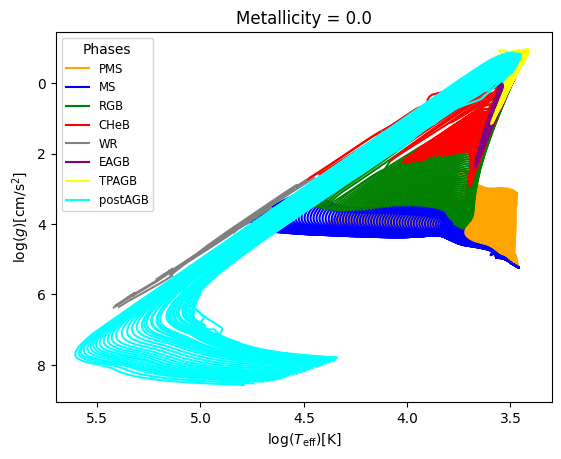

In [41]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.00,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.00,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.00,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.05,4.482577,4.350883,0.0,-0.25,12.925175,0.596074
4,5.05,4.485667,4.349692,0.0,-0.25,13.105490,0.600130
...,...,...,...,...,...,...,...
519286,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
519287,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
519288,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
519289,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


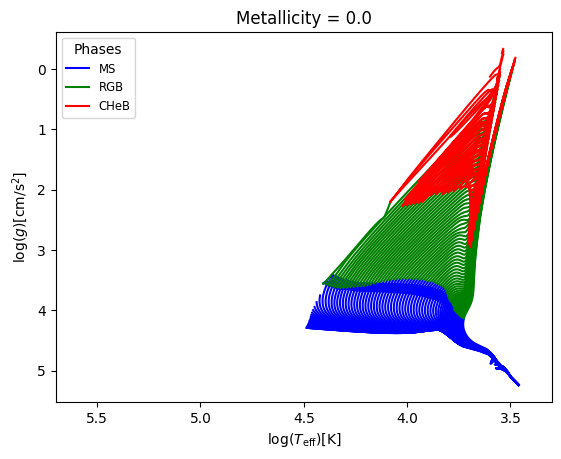

In [42]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [43]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4629, Median : 8.5

log_Teff  : Range : 3.34 - 4.6345, Mean : 3.9346, Median : 3.8644

log_g  : Range : -1.08 - 5.4331, Mean : 3.5485, Median : 3.9492

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 13.9995, Mean : 3.398, Median : 2.0471

log_R  : Range : -1.0 - 3.0828, Mean : 0.6067, Median : 0.5386



In [44]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.0464342686349397
Mean value in train data for the star_mass parameter: 3.3973846370701644

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.048860774010381
Mean value in test data for the star_mass parameter: 3.399812923045874

Range in test data for the log_R parameter : -0.9974234436680278 - 3.0827540579576227
Median value in test data for the log_R parameter: 0.5398730026691951
Mean value in test data for the log_R parameter: 0.6057854356870224

(389468, 4) (129823, 4)
(38

## Model training

### Linear regression

In [45]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.6370574929865372
  RMSE :  1.9853490880952078
  MAE :  1.5927686378218897
  MedAE :  1.3029076395897174
  CORR :  0.8112544180607413
  MAX_ER :  7.730090631887342
  Percentiles : 
    75th percentile :  2.2559772293242517
    90th percentile :  3.1240515226352756
    95th percentile :  3.6182028563921245
    99th percentile :  5.713701082309926

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.741946032563519
  RMSE :  1.6487042537290941
  MAE :  1.1424659728297122
  MedAE :  0.8820060433004432
  CORR :  0.8957299952059546
  MAX_ER :  7.43019121950981
  Percentiles : 
    75th percentile :  1.2592547922761625
    90th percentile :  2.243895568309891
    95th percentile :  4.0372065891750

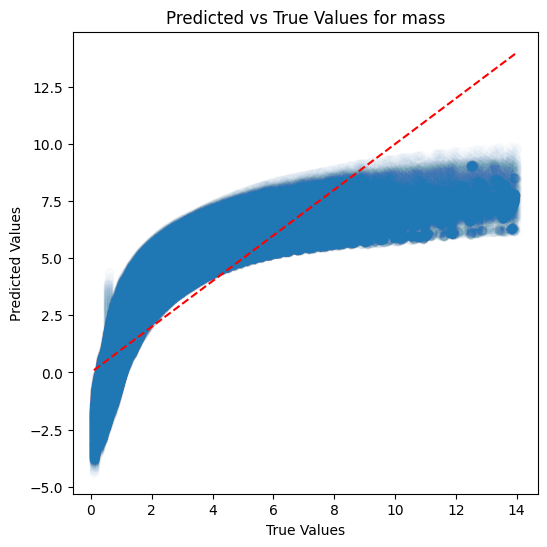

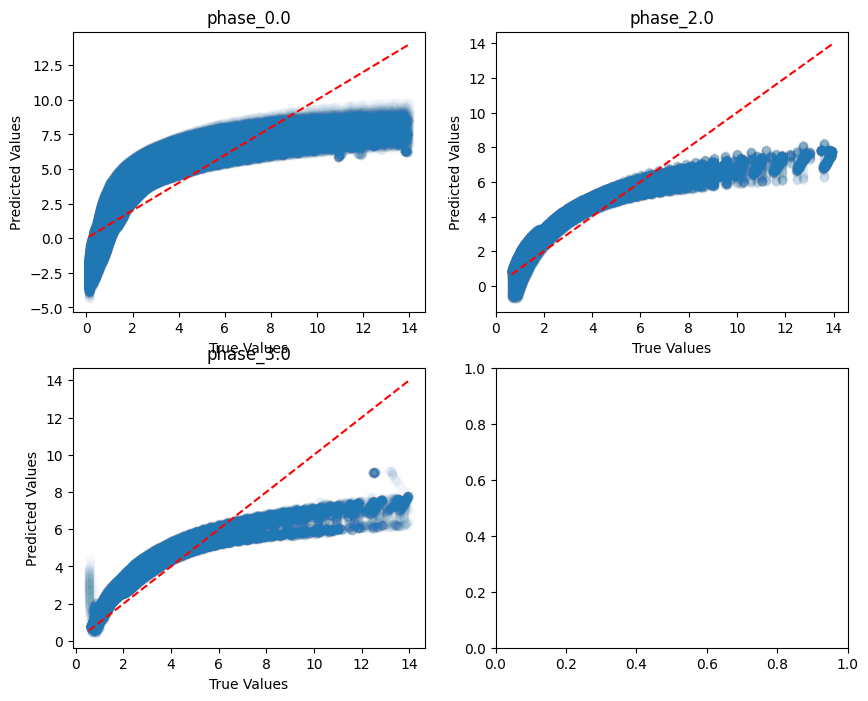

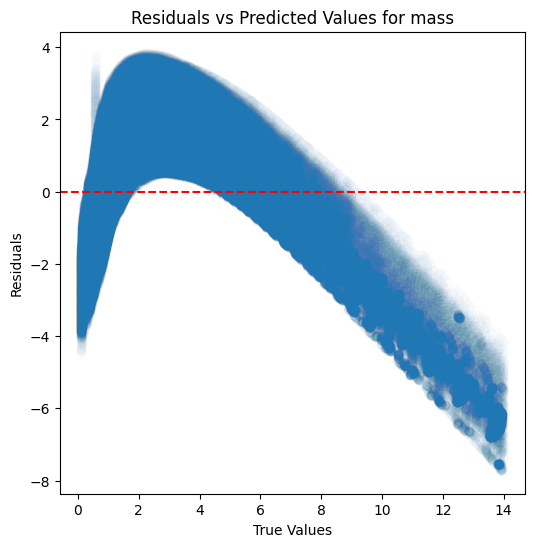

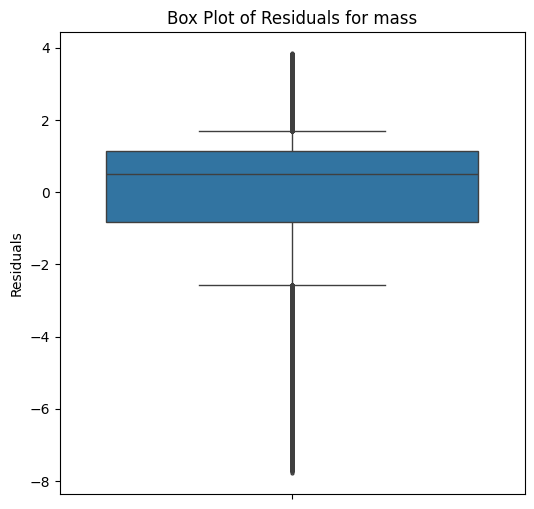

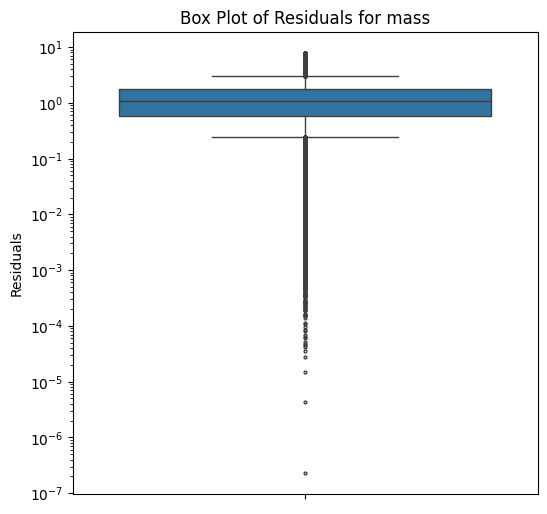

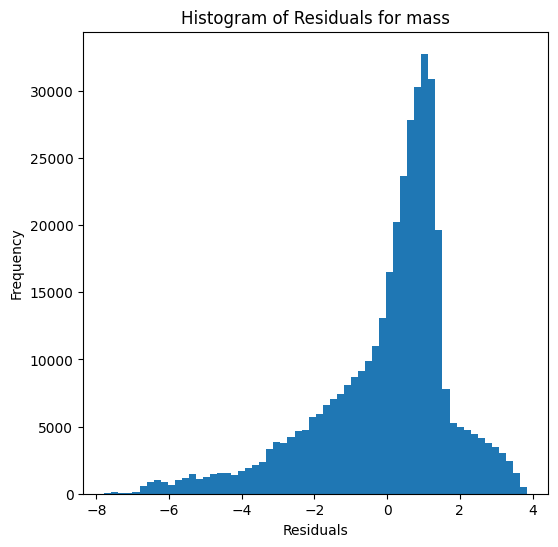

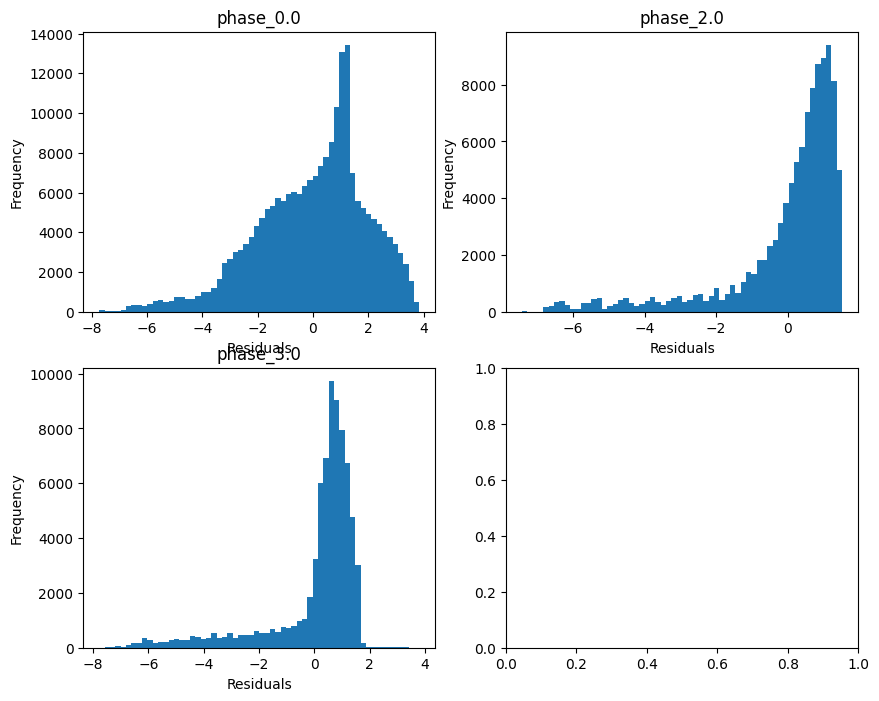

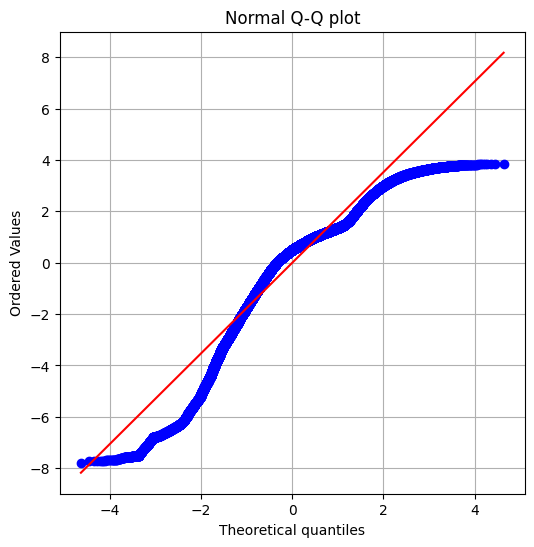

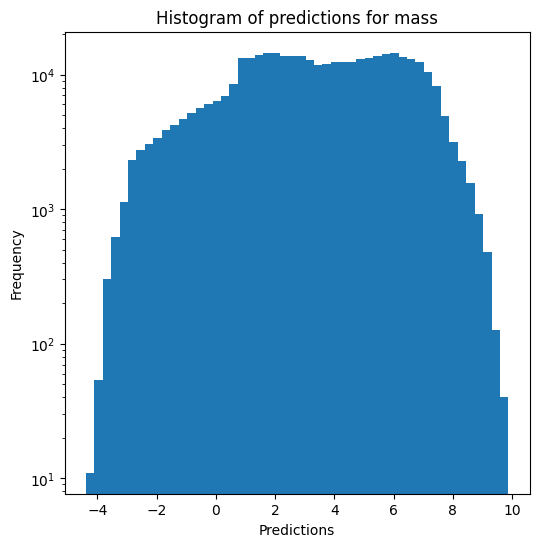

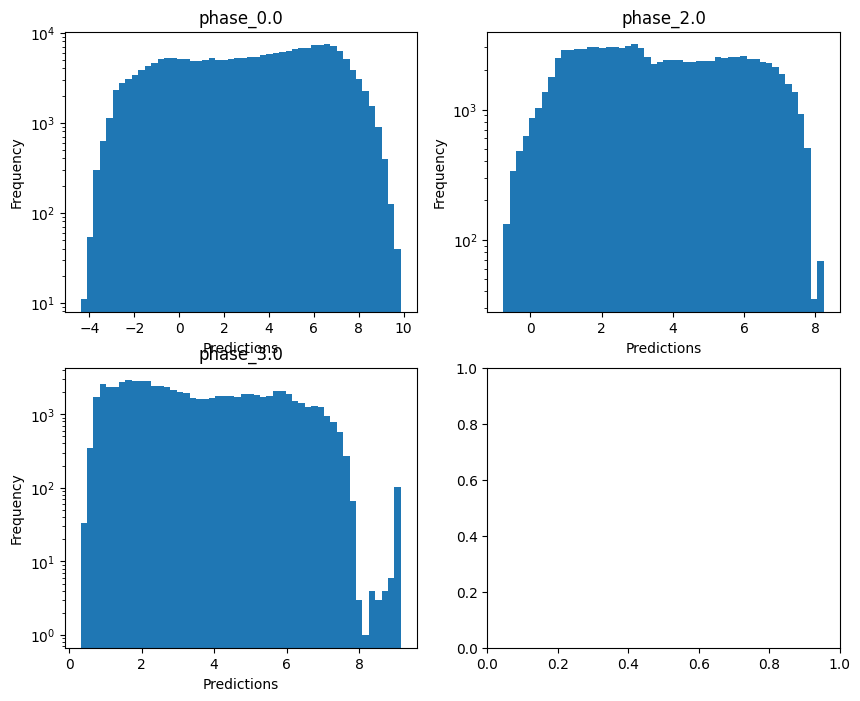

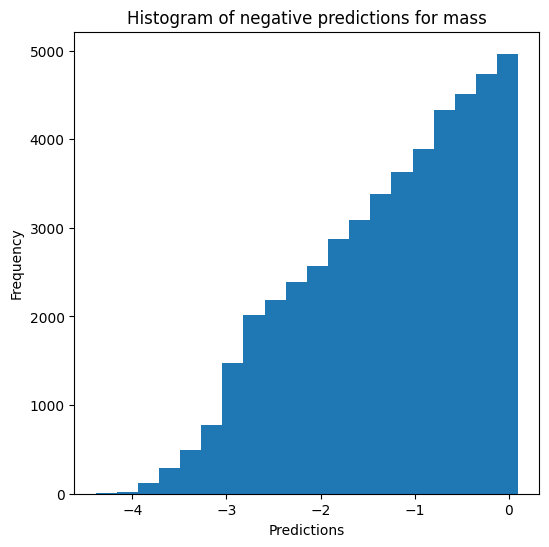


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9516113674775278
  RMSE :  0.09470766357638445
  MAE :  0.0751925669354003
  MedAE :  0.06458312010783968
  CORR :  0.9756081555902227
  MAX_ER :  0.783660692292182
  Percentiles : 
    75th percentile :  0.10983796585759498
    90th percentile :  0.1504825960902418
    95th percentile :  0.1732408456654069
    99th percentile :  0.22021027455278636

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9618328301811866
  RMSE :  0.09791200899159468
  MAE :  0.08060857806126794
  MedAE :  0.07937553974858388
  CORR :  0.9820478703101309
  MAX_ER :  0.6227026053110238
  Percentiles : 
    75th percentile :  0.10937918899661514
    90th percentile :  0.13103886829445147
    95th percentile :  0.14225101965553236
    99th percentile :  0.30113772115296206

radius results for the phase category

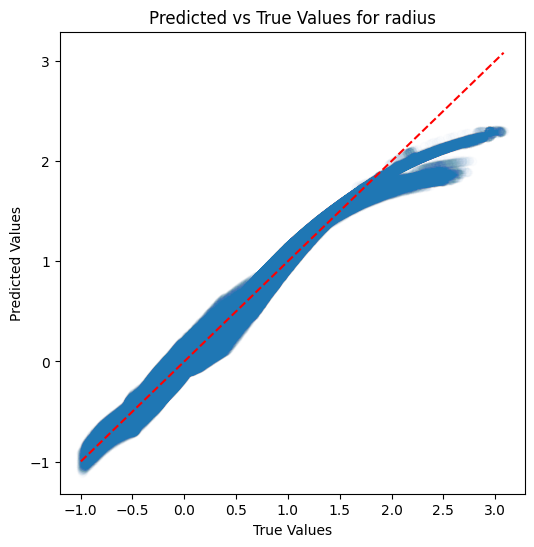

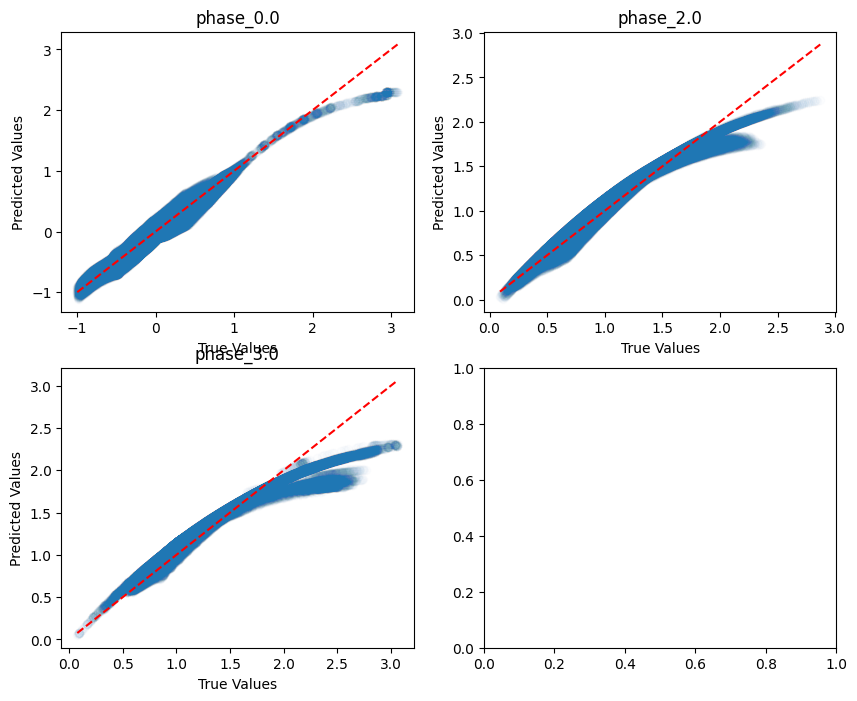

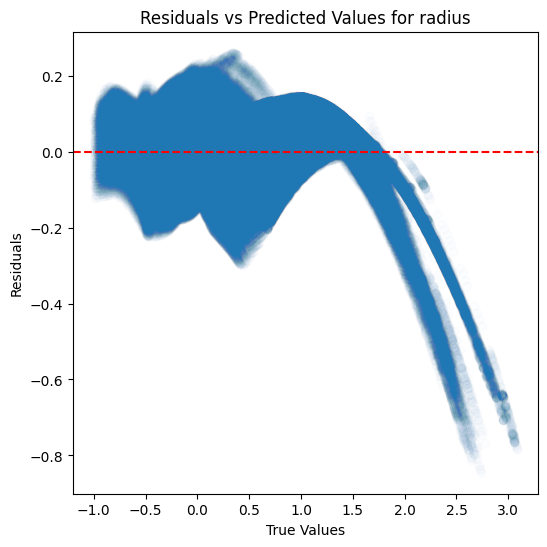

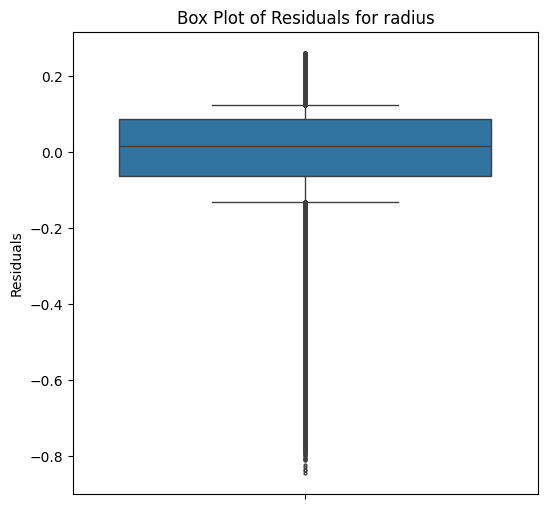

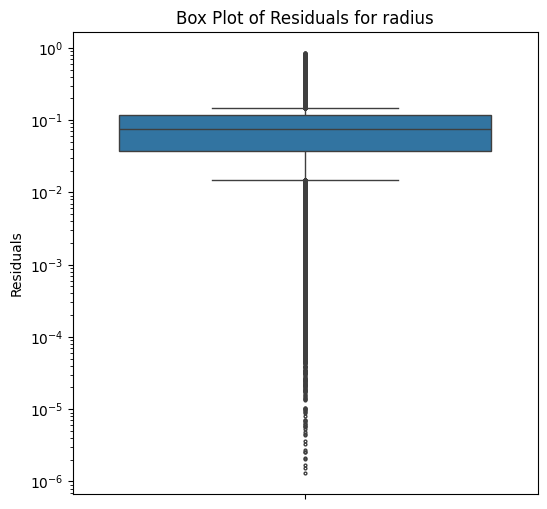

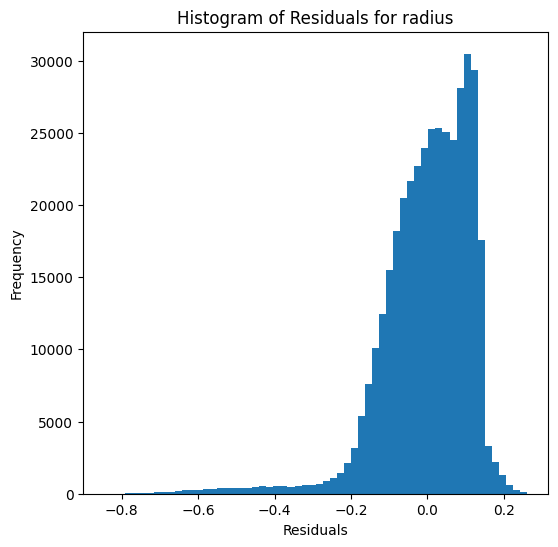

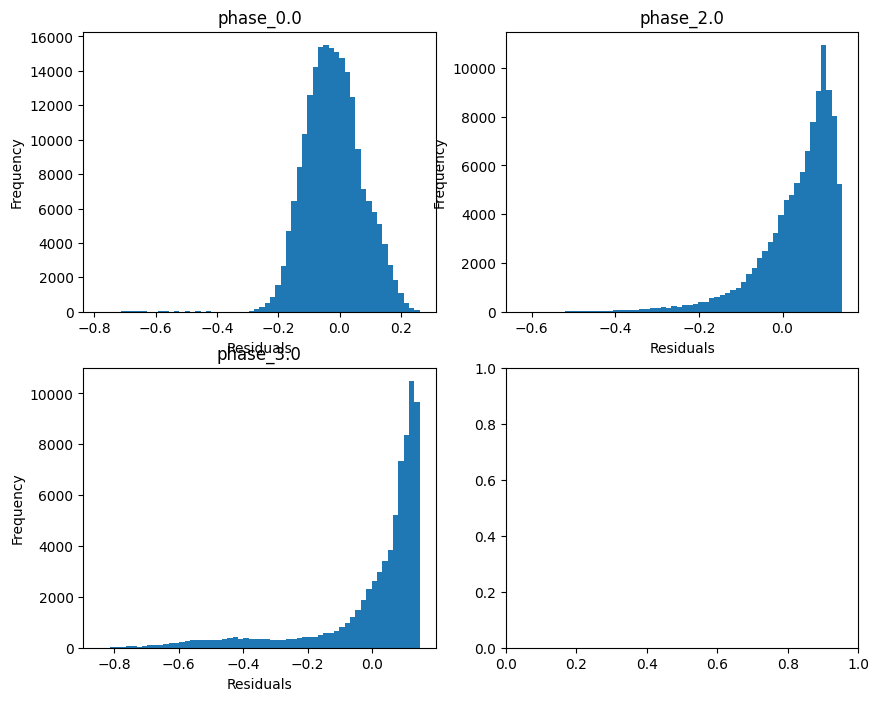

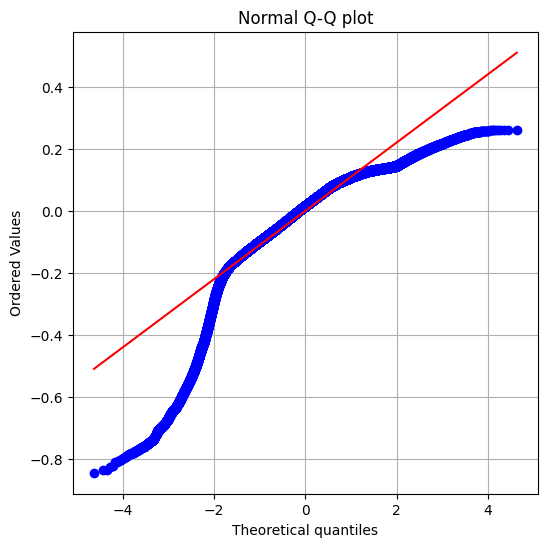

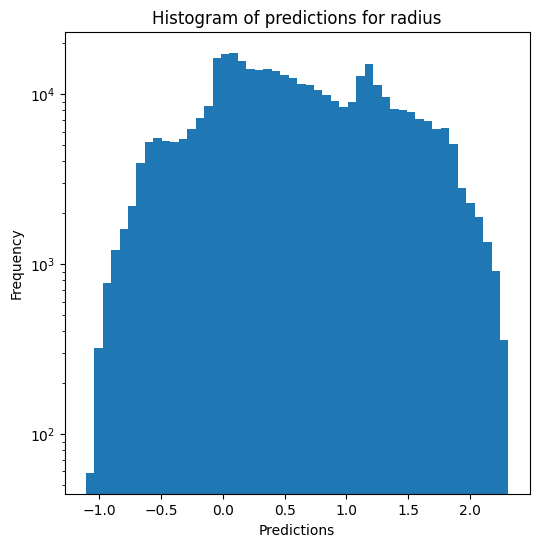

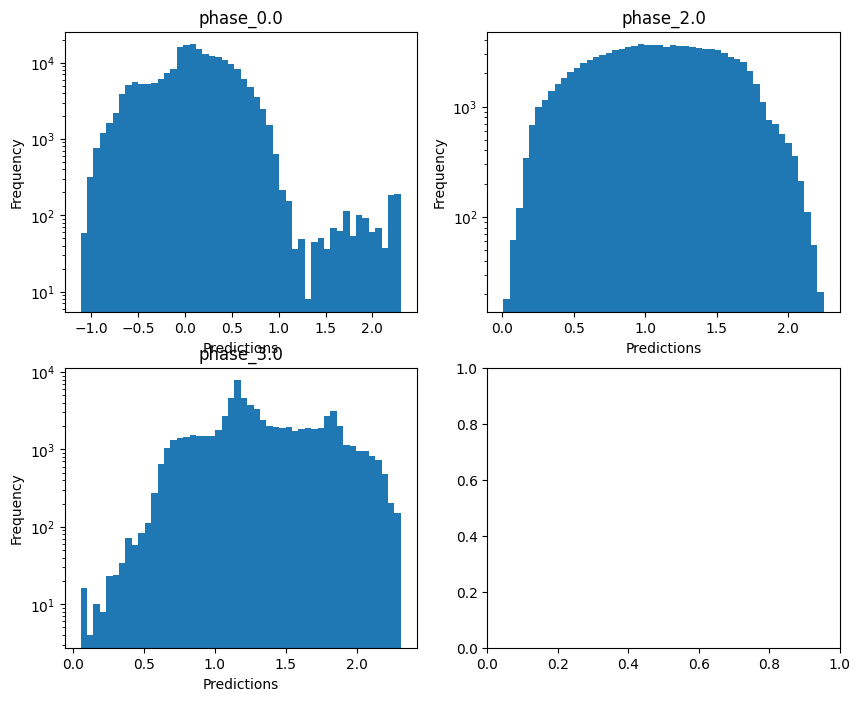

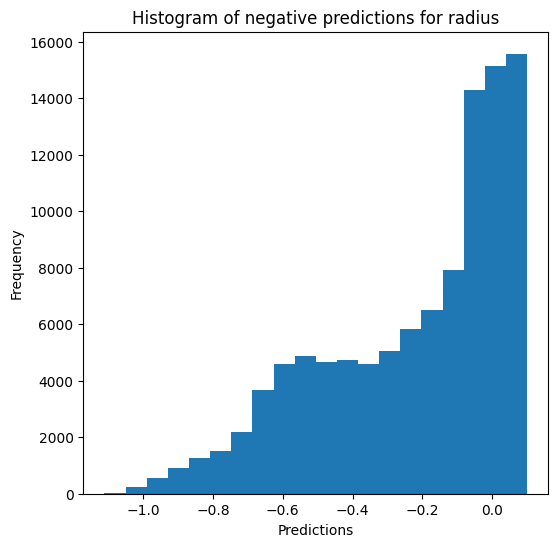

Saving predictions and results...


In [46]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [47]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997556093085673
  RMSE :  0.05151837232415874
  MAE :  0.016987928113630448
  MedAE :  0.004116055772740879
  CORR :  0.9998778036514527
  MAX_ER :  5.054212555120426
  Percentiles : 
    75th percentile :  0.013642898035103102
    90th percentile :  0.04221003010879798
    95th percentile :  0.0740279416972103
    99th percentile :  0.19594833437023032

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999408009998965
  RMSE :  0.025001524324624543
  MAE :  0.007699271269038167
  MedAE :  0.00032509600107399894
  CORR :  0.9999705306146504
  MAX_ER :  1.4104238006648107
  Percentiles : 
    75th percentile :  0.005801892477371284
    90th percentile :  0.023484236029657848
    95th per

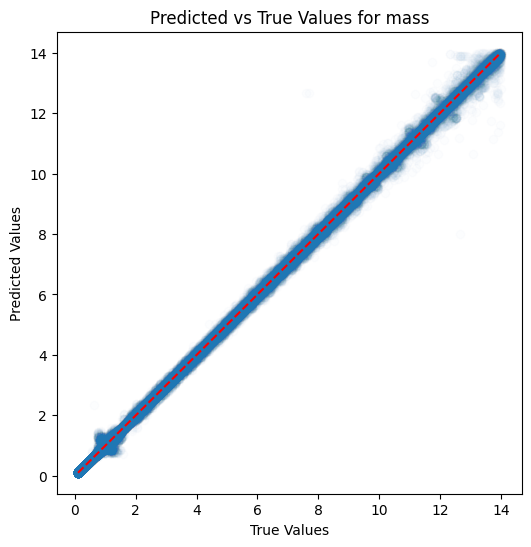

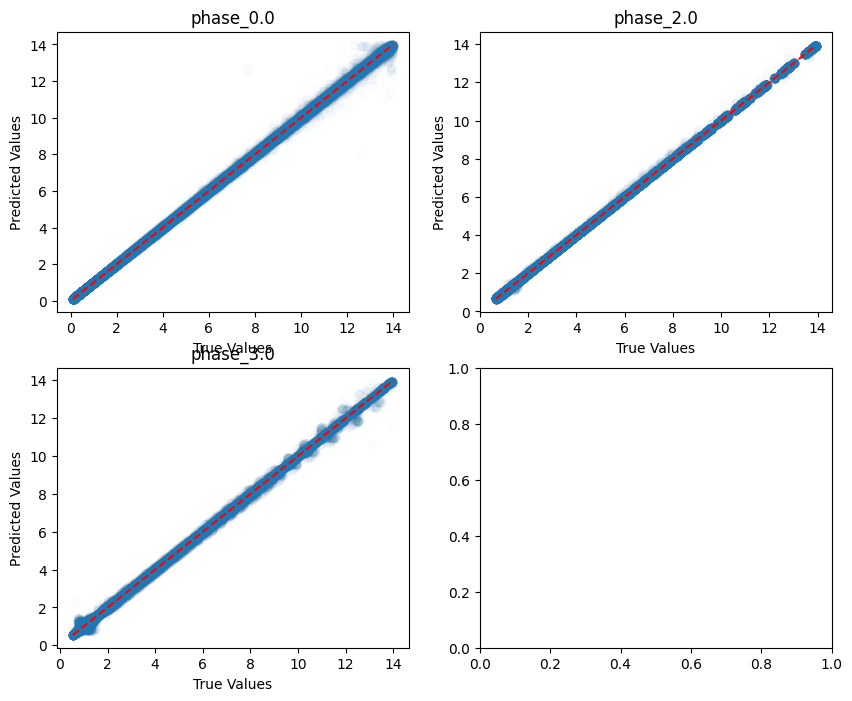

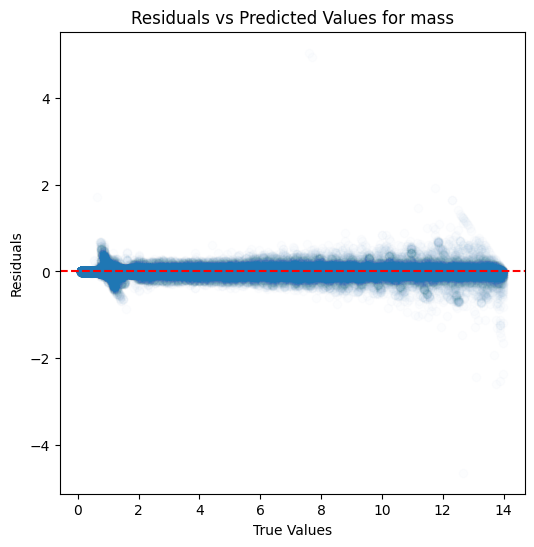

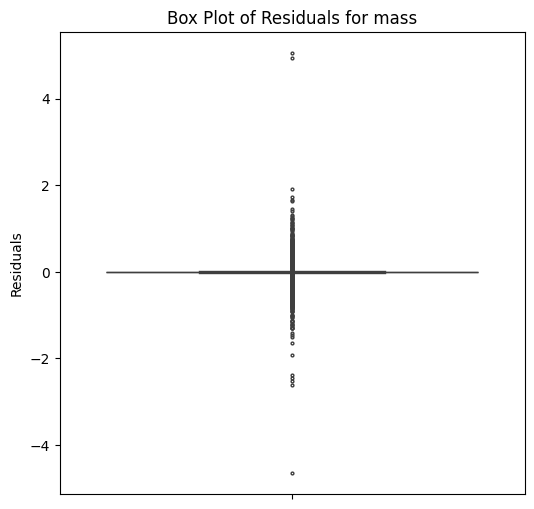

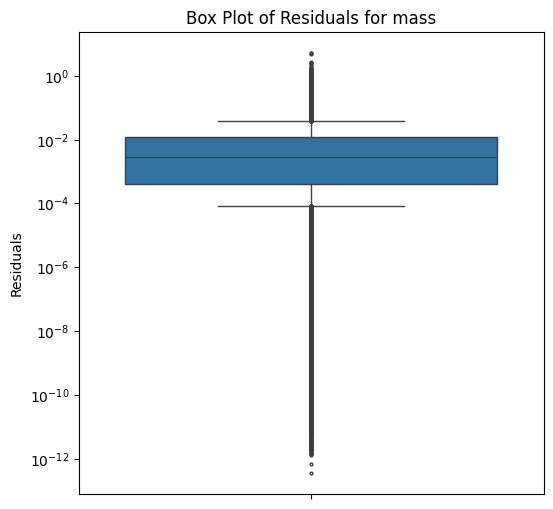

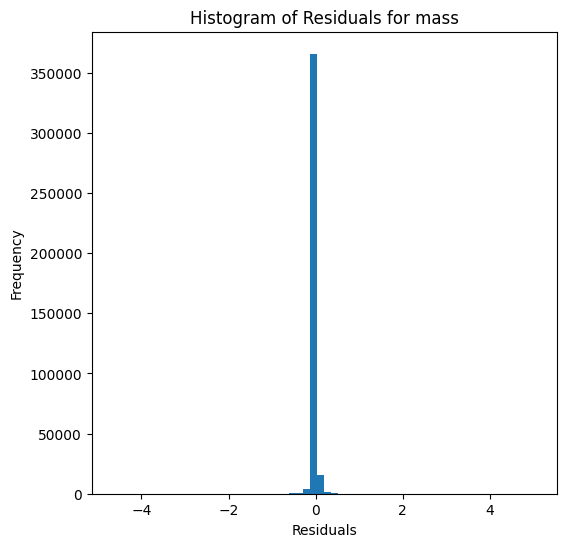

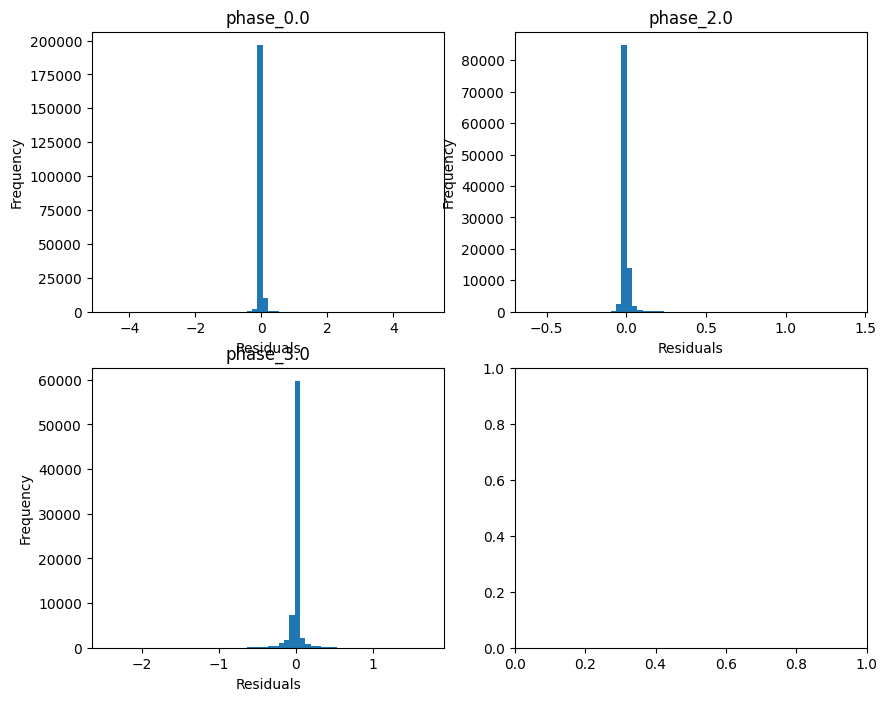

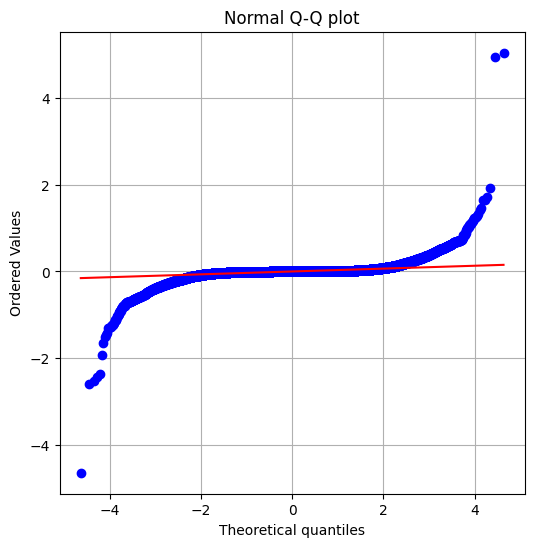

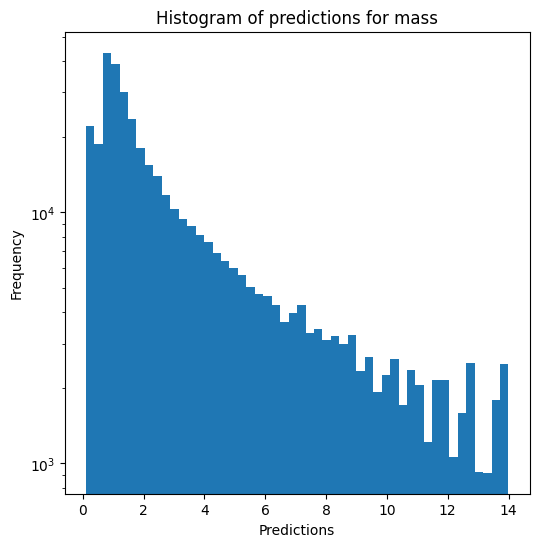

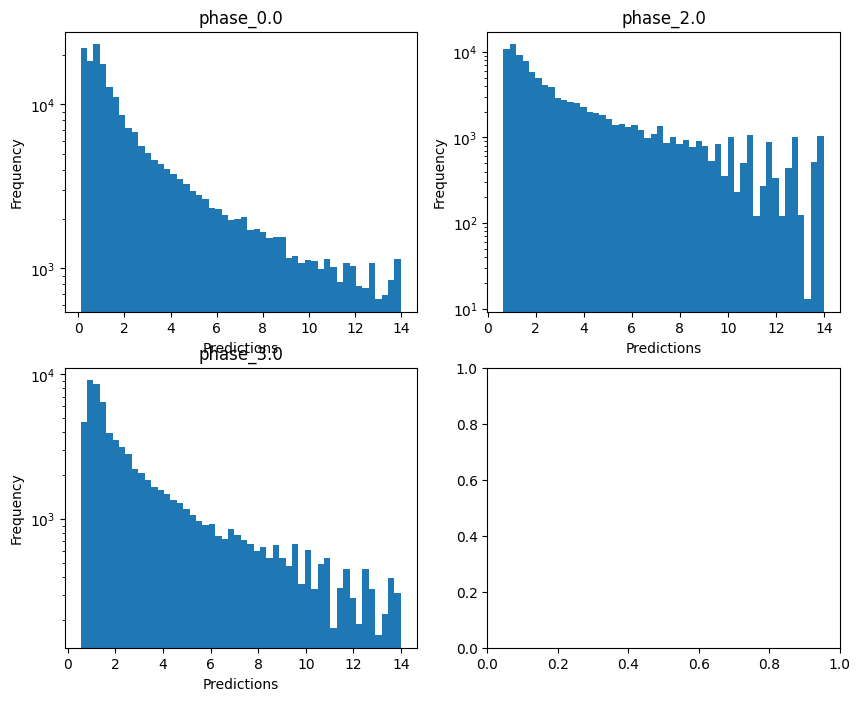

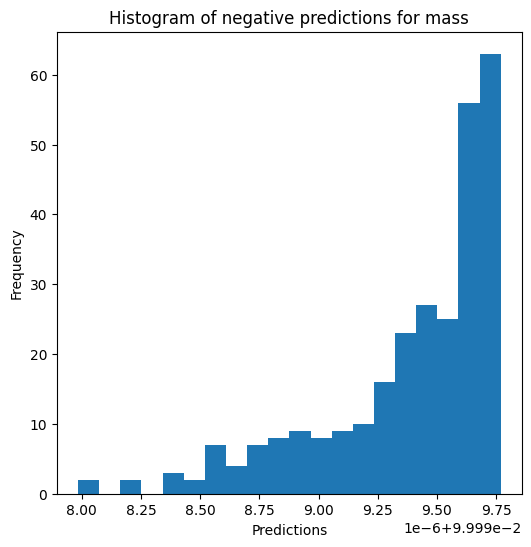


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9997879353990672
  RMSE :  0.006139847877523113
  MAE :  0.003632115525476511
  MedAE :  0.002281108101354956
  CORR :  0.9998939693347667
  MAX_ER :  0.3111731559611798
  Percentiles : 
    75th percentile :  0.0045623208905165025
    90th percentile :  0.00803229101560863
    95th percentile :  0.011293963961338102
    99th percentile :  0.023918765293507435

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9995031956101705
  RMSE :  0.010389932407457728
  MAE :  0.007337985418575173
  MedAE :  0.006029761373778919
  CORR :  0.9997530574183836
  MAX_ER :  0.3767123245315078
  Percentiles : 
    75th percentile :  0.00982248996482682
    90th percentile :  0.0138352862200843
    95th percentile :  0.017262762911020583
    99th percentile :  0.03190027867521458

radius results for the 

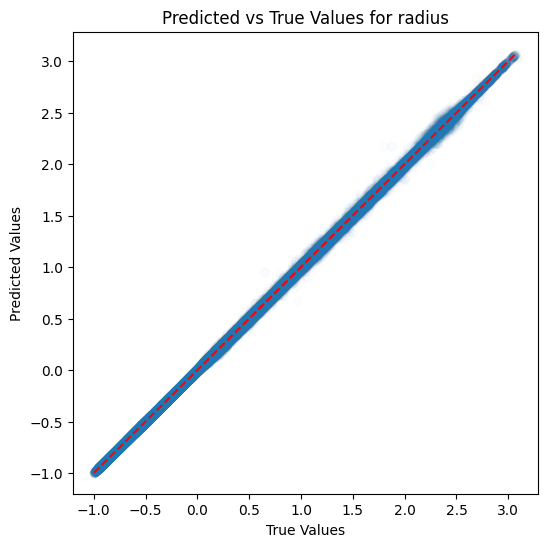

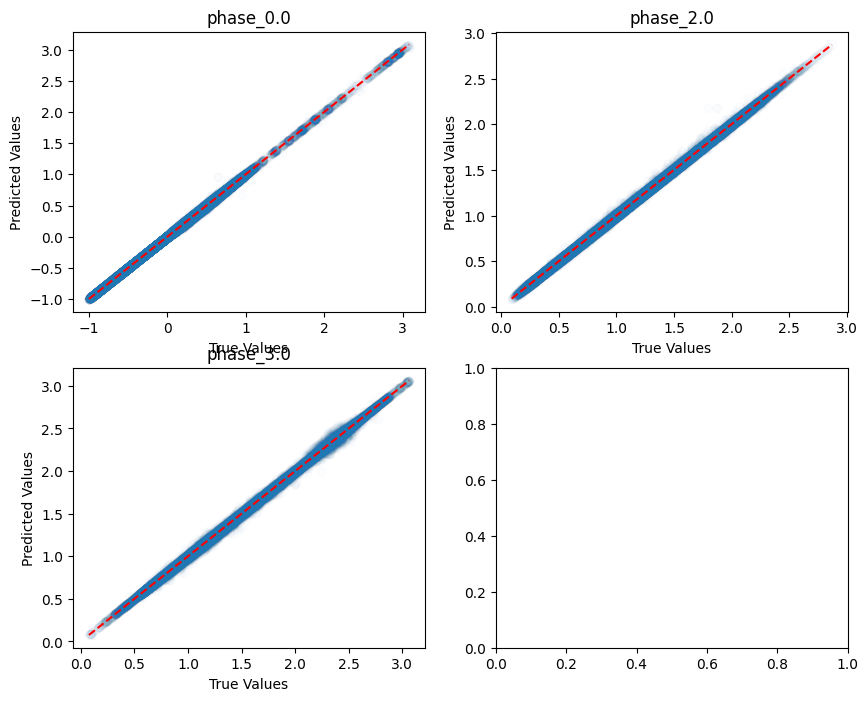

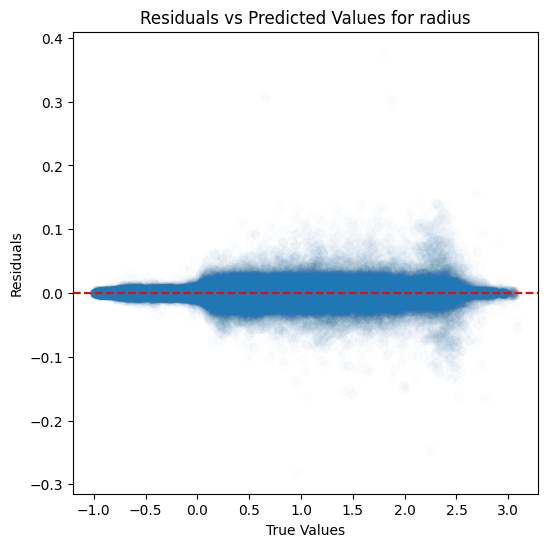

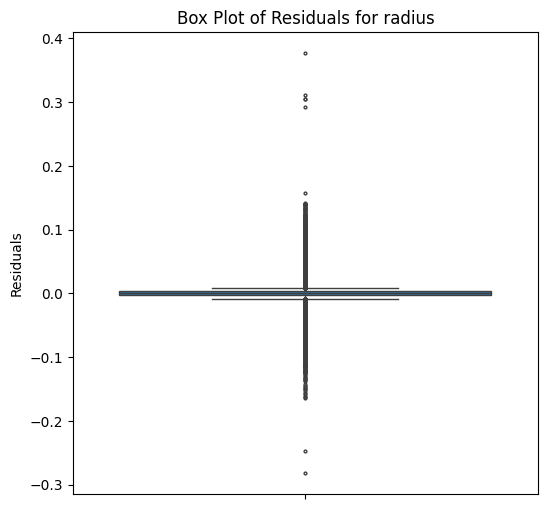

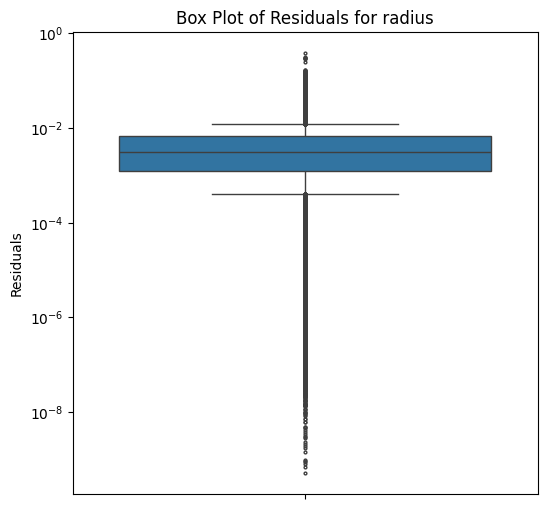

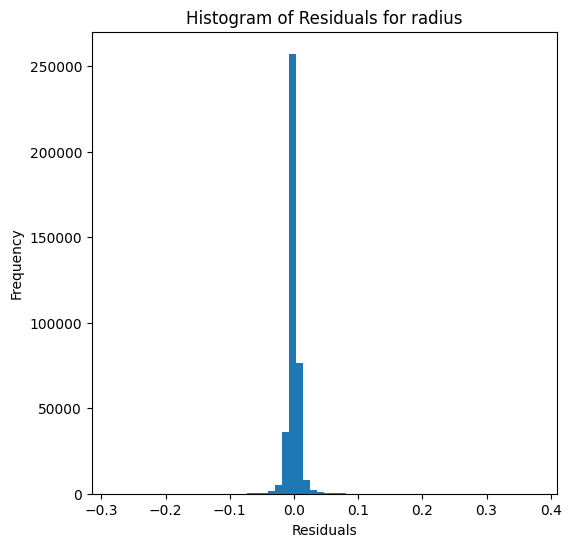

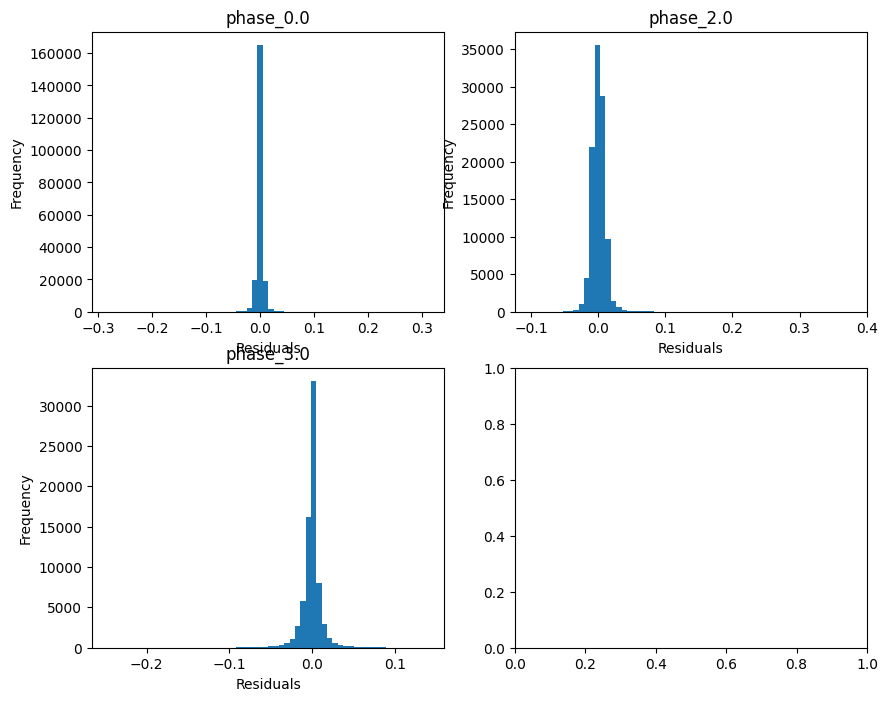

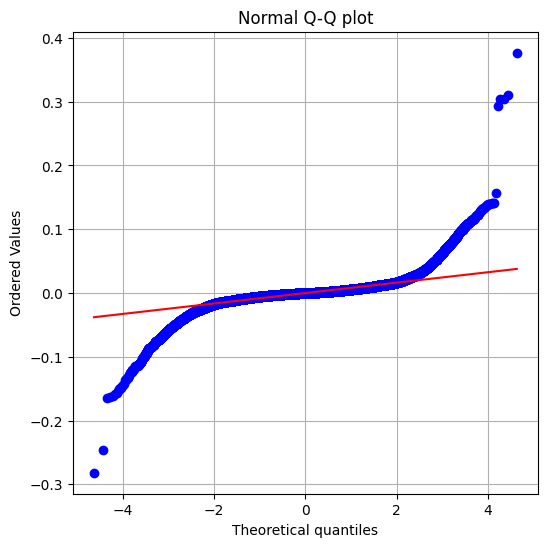

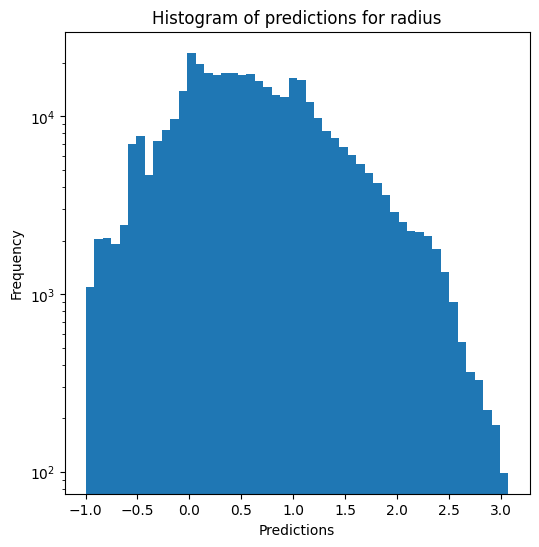

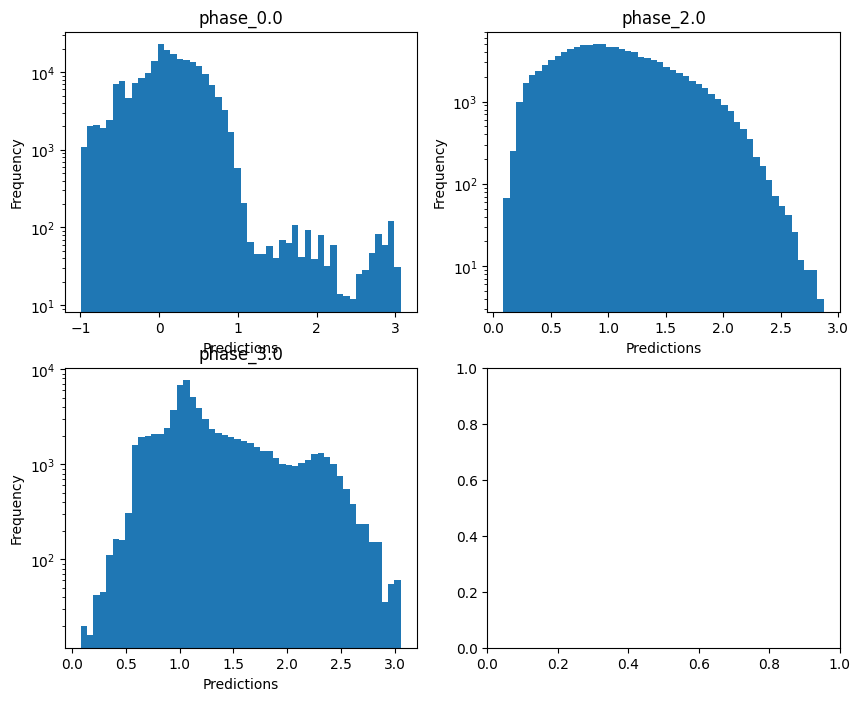

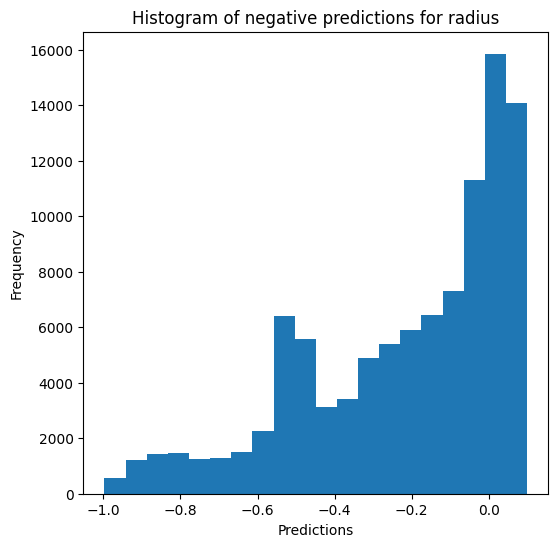

Saving predictions and results...


In [48]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [49]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997411194432794
  RMSE :  0.0530231790747254
  MAE :  0.01992934414283062
  MedAE :  0.004538325076334893
  CORR :  0.9998712322421227
  MAX_ER :  2.566355170711793
  Percentiles : 
    75th percentile :  0.016186162666380843
    90th percentile :  0.052689551334936205
    95th percentile :  0.09339921259239965
    99th percentile :  0.22202200787883578

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997383989335838
  RMSE :  0.052505693143738534
  MAE :  0.019669736314367137
  MedAE :  0.0029277636415292463
  CORR :  0.9998693543087607
  MAX_ER :  0.984755517697014
  Percentiles : 
    75th percentile :  0.013918944914202092
    90th percentile :  0.05655622991094

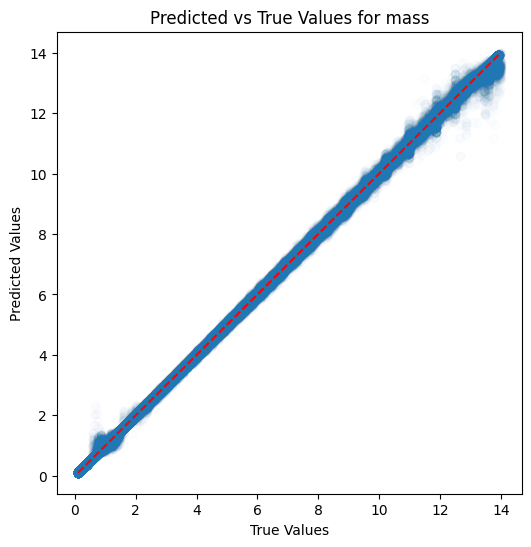

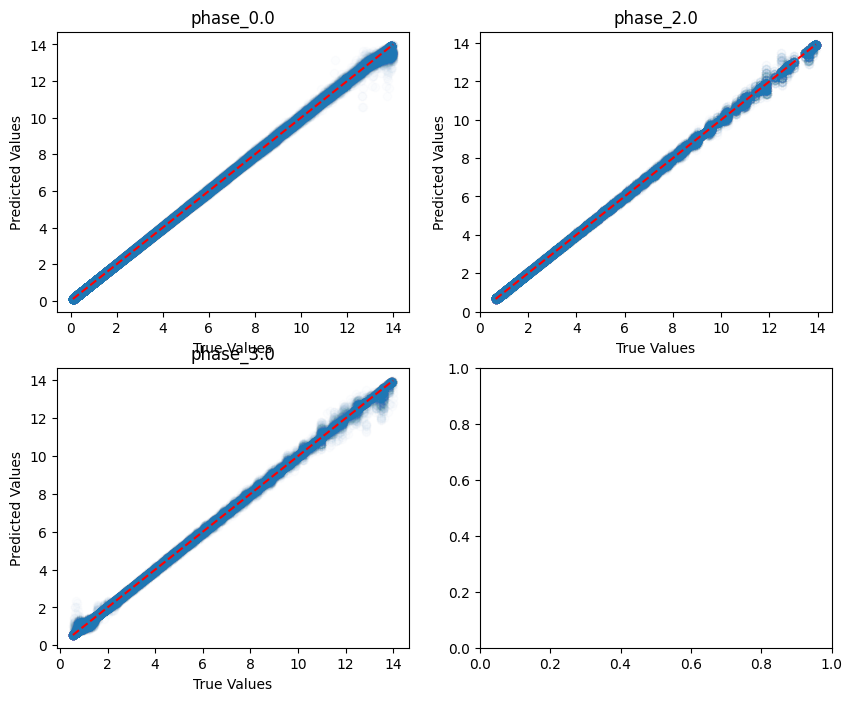

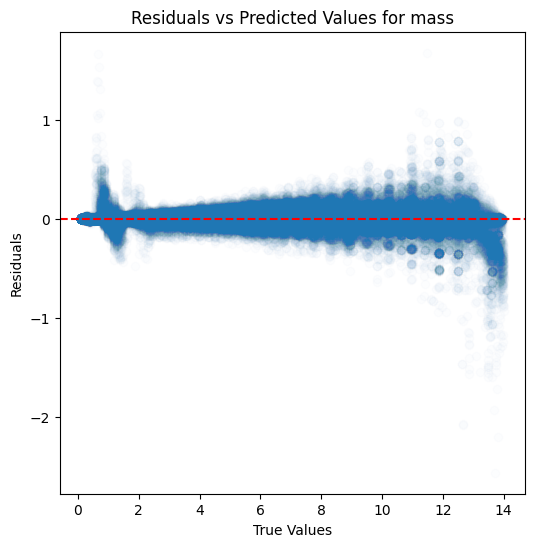

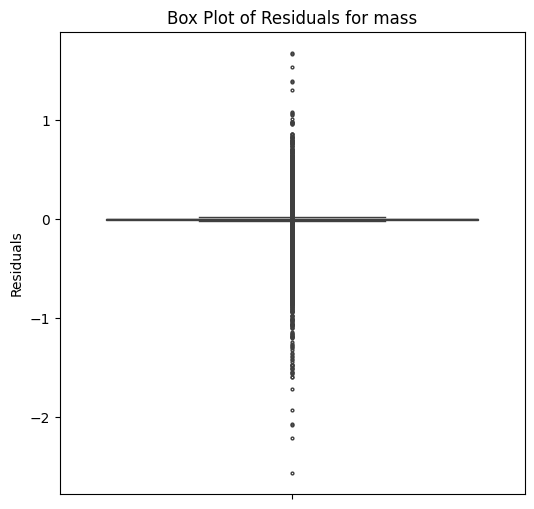

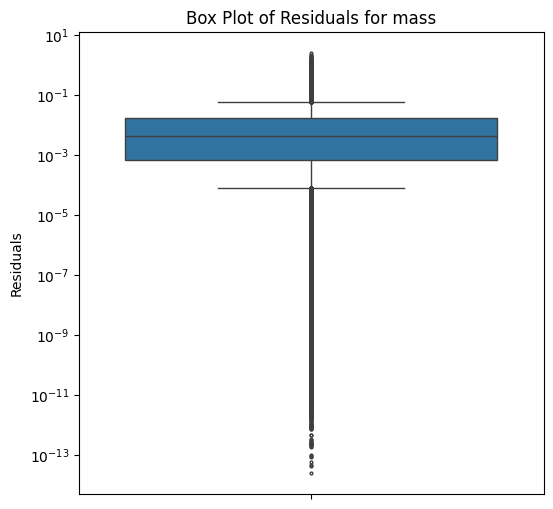

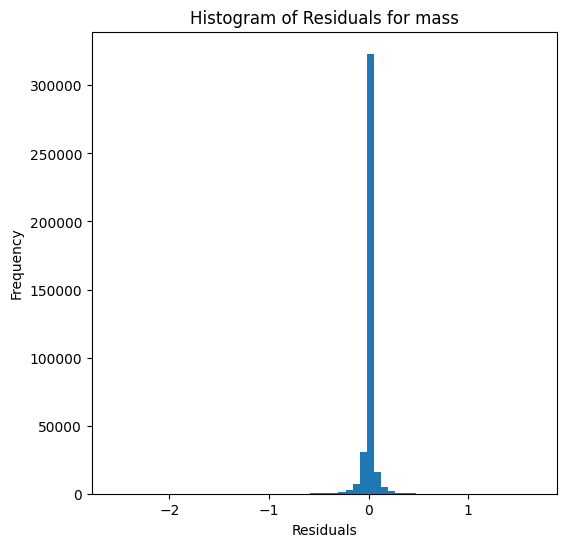

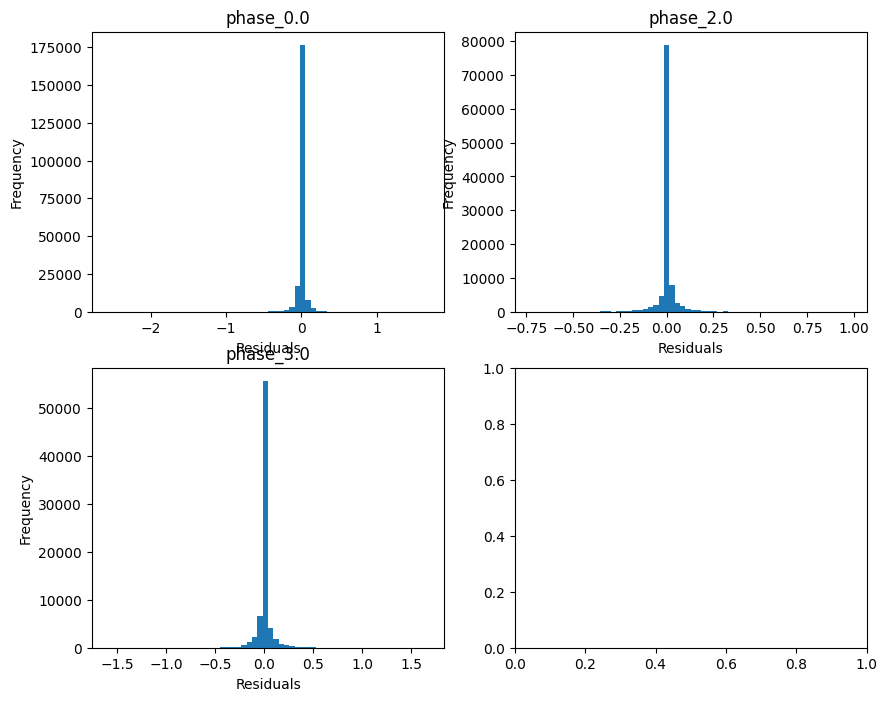

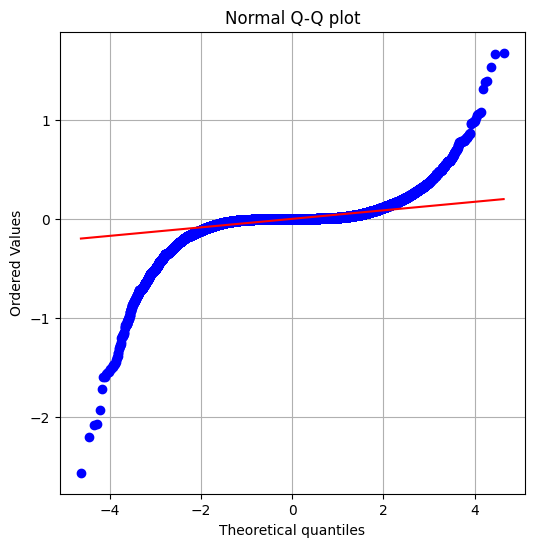

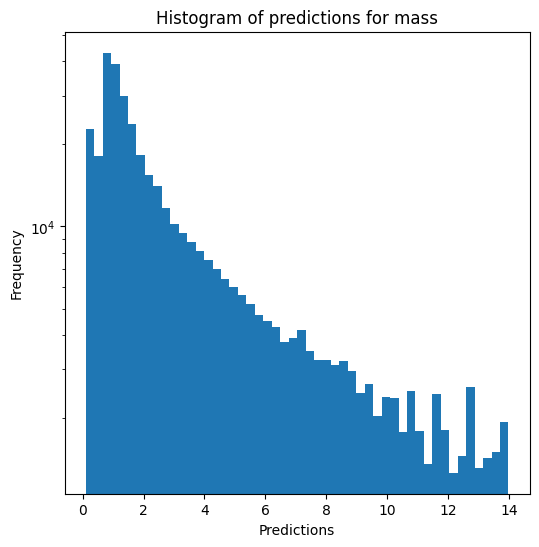

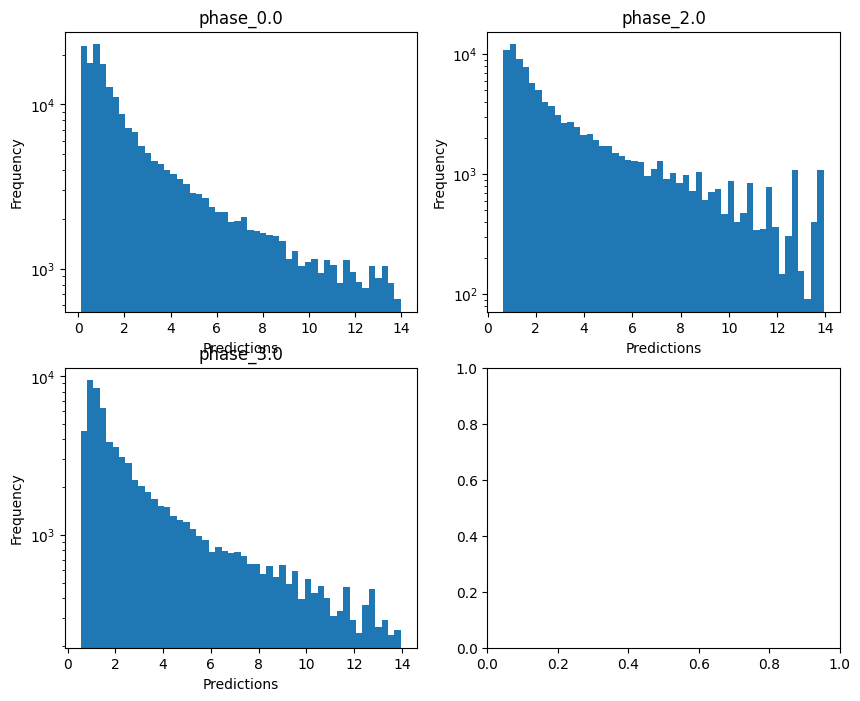


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999102388365776
  RMSE :  0.003991206489073969
  MAE :  0.002722268220803085
  MedAE :  0.0019042966071769474
  CORR :  0.999955320302227
  MAX_ER :  0.08490805502905552
  Percentiles : 
    75th percentile :  0.003563999844744953
    90th percentile :  0.006119165534417609
    95th percentile :  0.00820701942277797
    99th percentile :  0.01381736880765374

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9998064010365285
  RMSE :  0.006592639299949913
  MAE :  0.004926760989500045
  MedAE :  0.003710342731037708
  CORR :  0.9999046673445448
  MAX_ER :  0.052931518697536095
  Percentiles : 
    75th percentile :  0.006732910584092422
    90th percentile :  0.010704647432544468
    95th percentile :  0.013716009650079302
    99th percentile :  0.0202856924169416

radius results for t

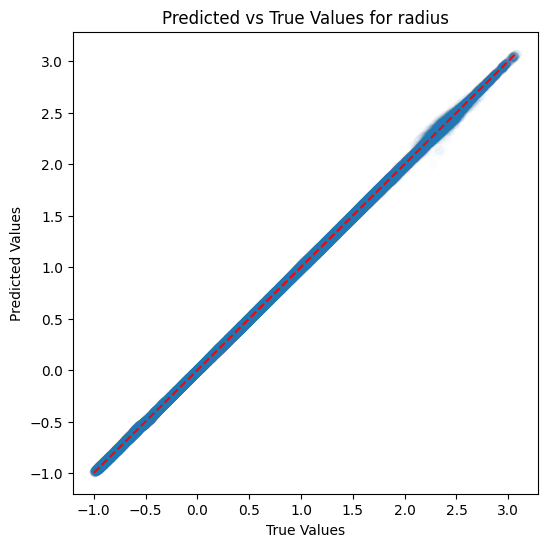

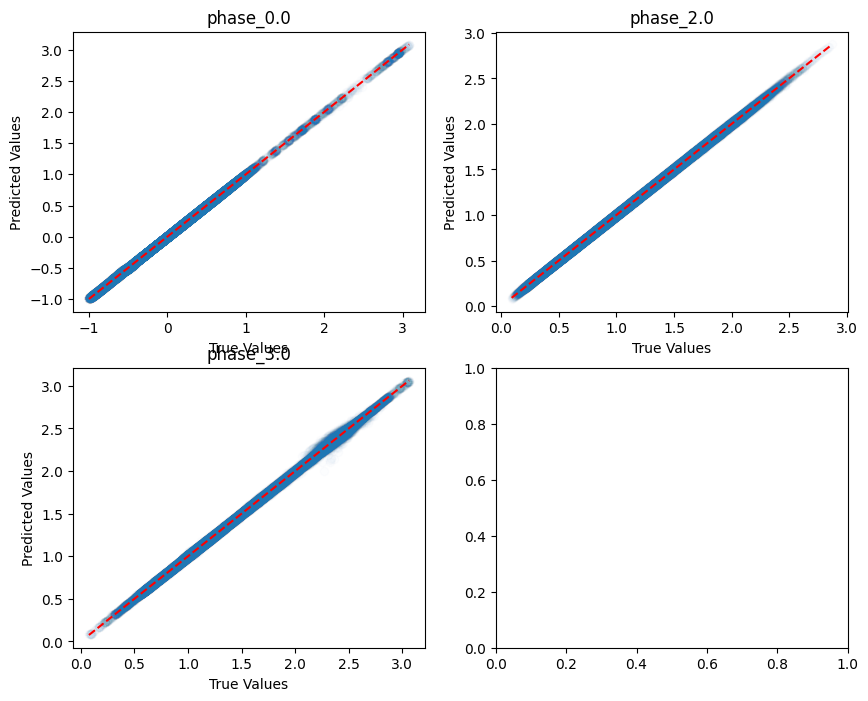

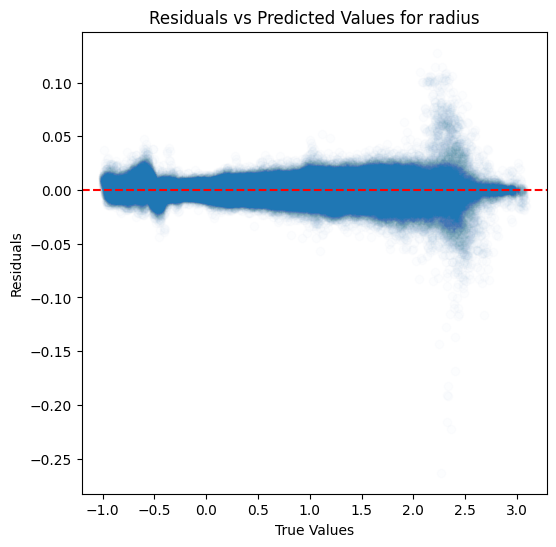

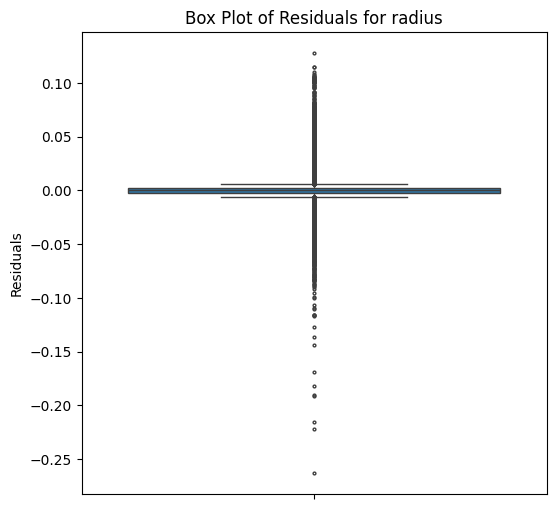

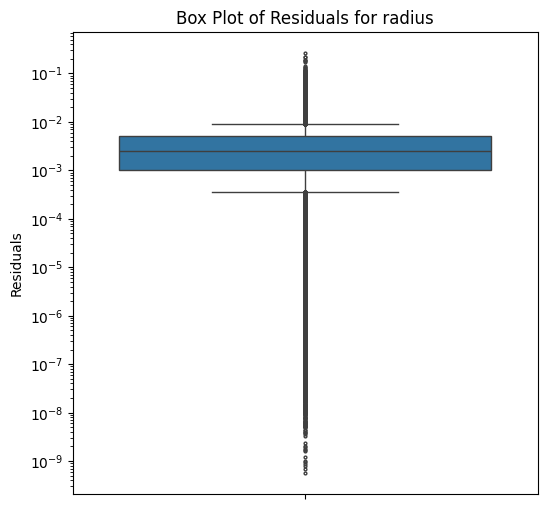

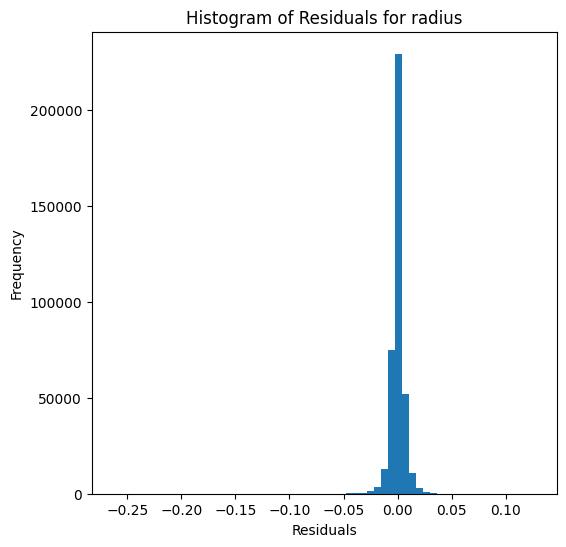

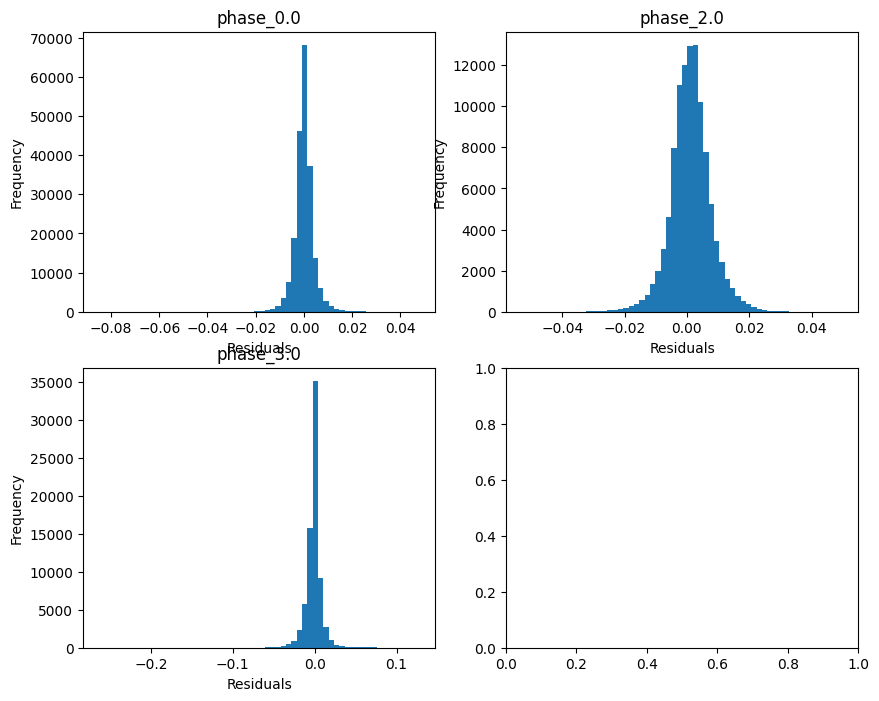

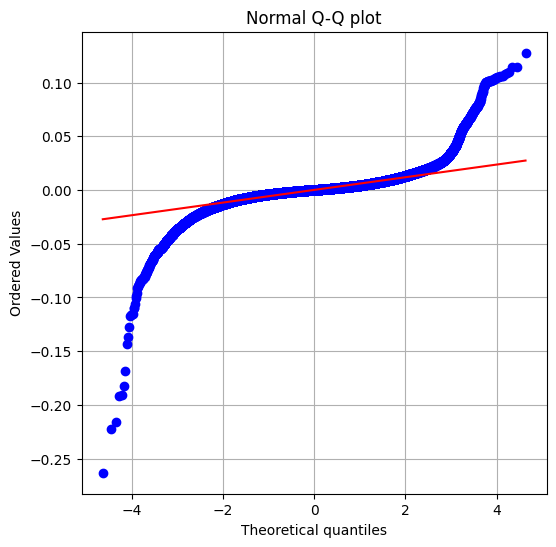

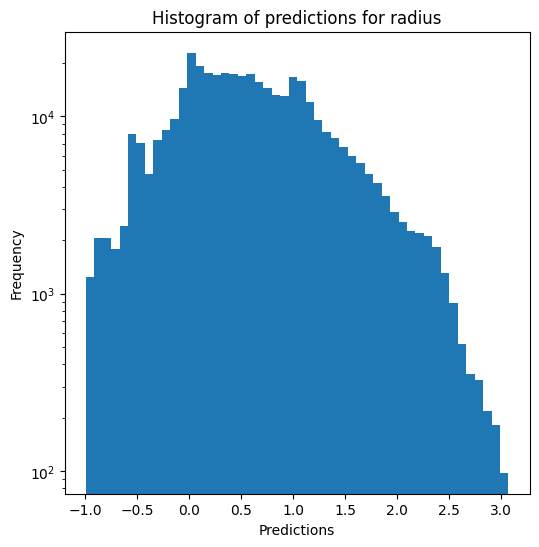

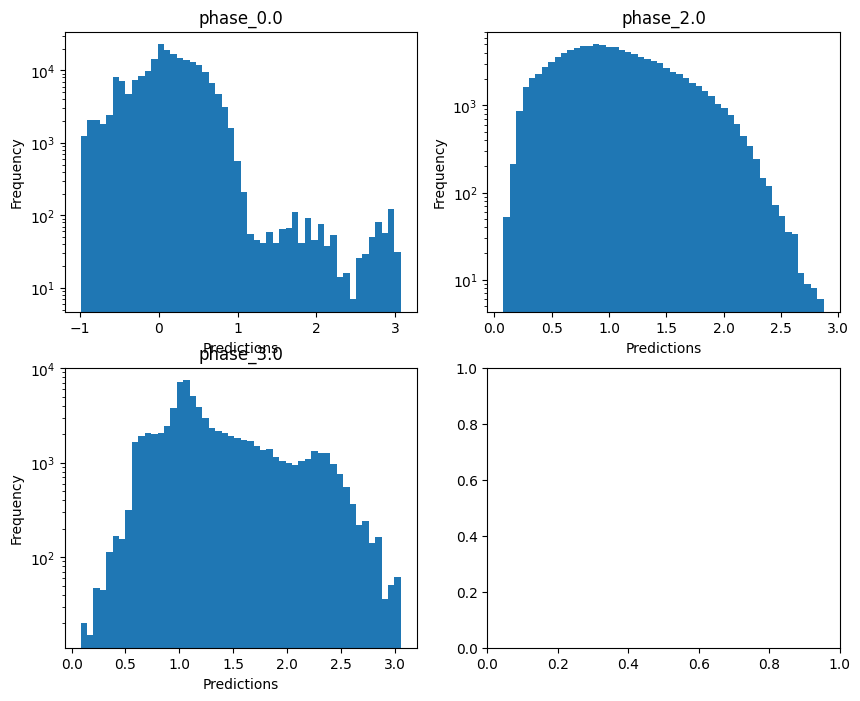

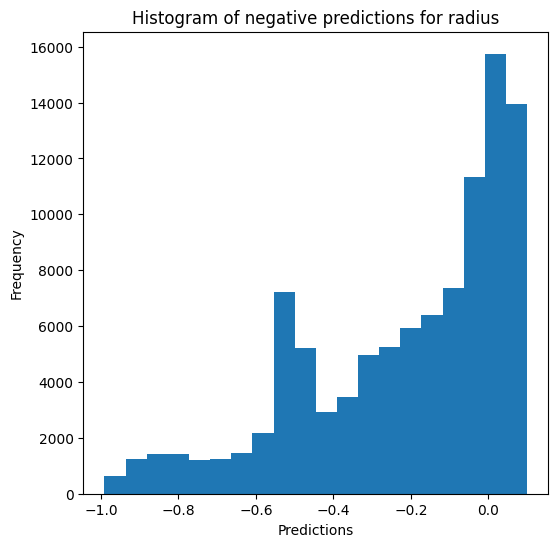

Saving predictions and results...


In [50]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [51]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9999229048489929
  RMSE :  0.028936233318692463
  MAE :  0.008835659323957253
  MedAE :  0.0024451625591970227
  CORR :  0.9999614651747163
  MAX_ER :  2.327538744953621
  Percentiles : 
    75th percentile :  0.0071662045072322655
    90th percentile :  0.019767626858376453
    95th percentile :  0.03501069097441714
    99th percentile :  0.10255901557487226

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999736745225538
  RMSE :  0.016751373388319626
  MAE :  0.00842211395926568
  MedAE :  0.004367915166118452
  CORR :  0.9999869932874911
  MAX_ER :  0.4988755540727663
  Percentiles : 
    75th percentile :  0.010067426463307827
    90th percentile :  0.018918896985600484
    95th p

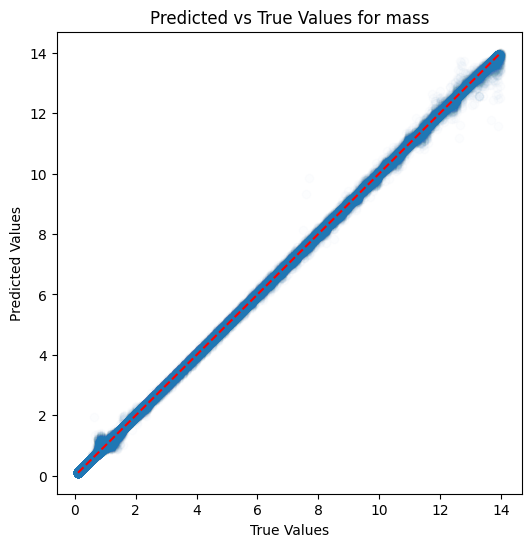

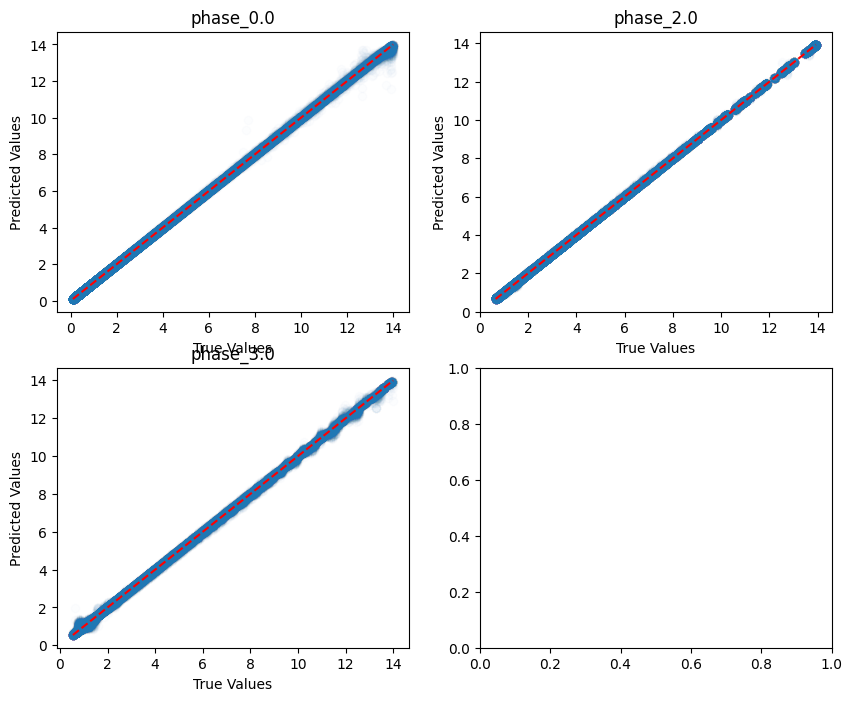

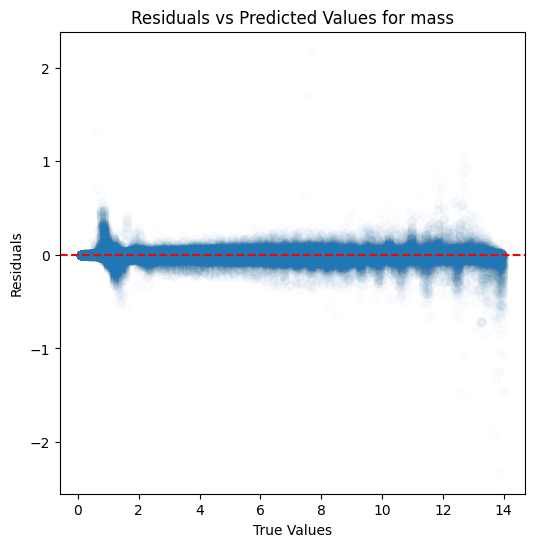

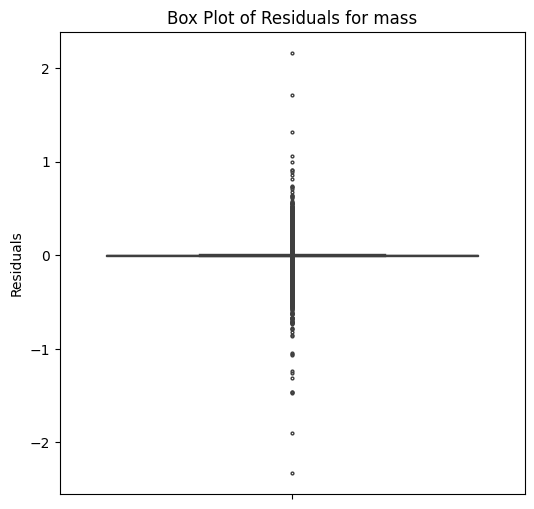

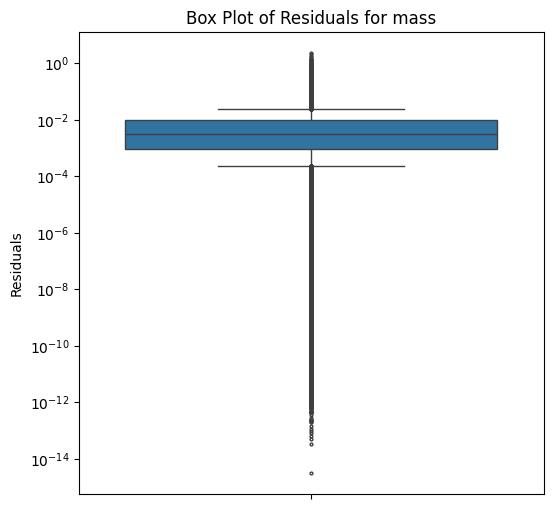

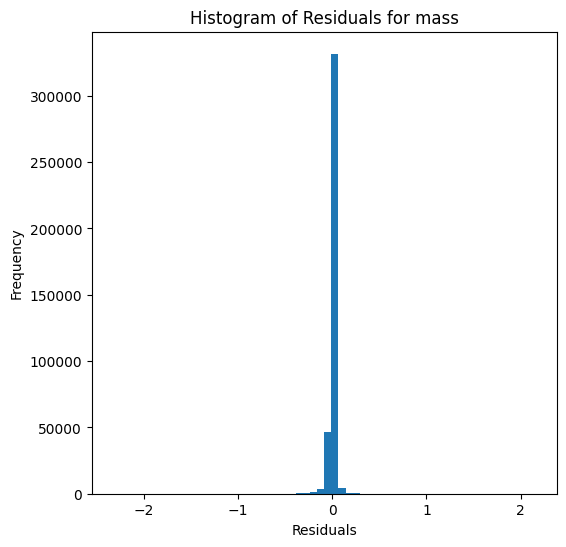

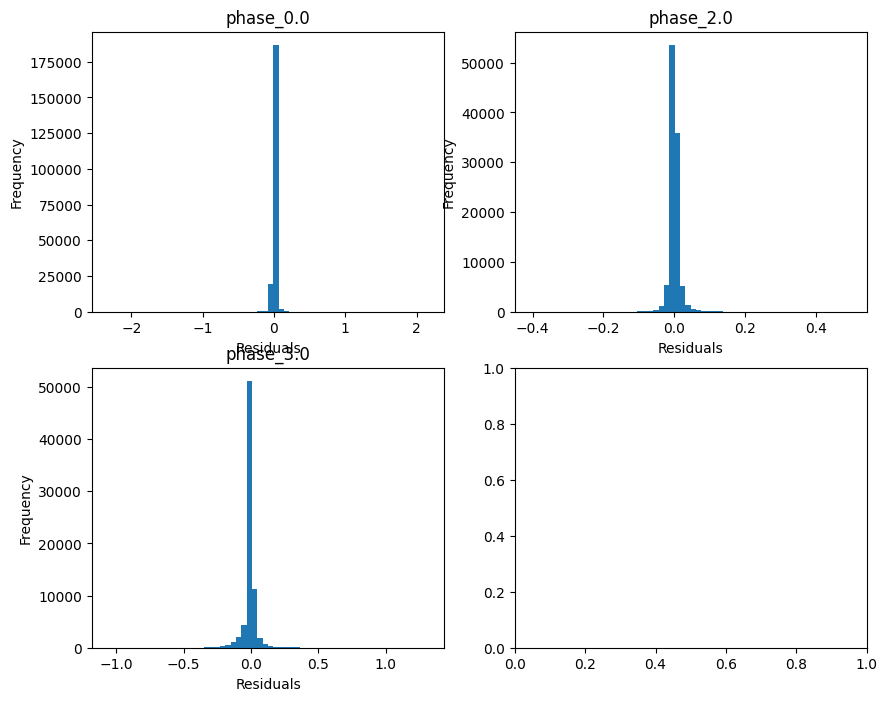

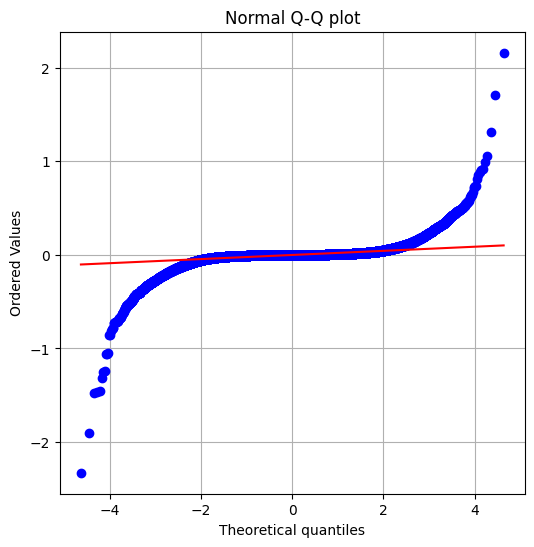

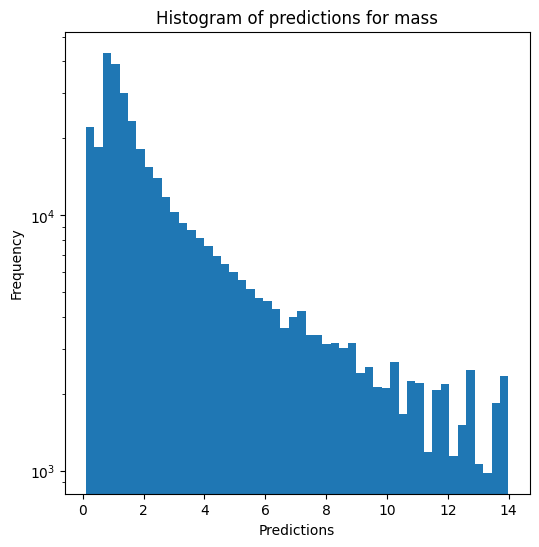

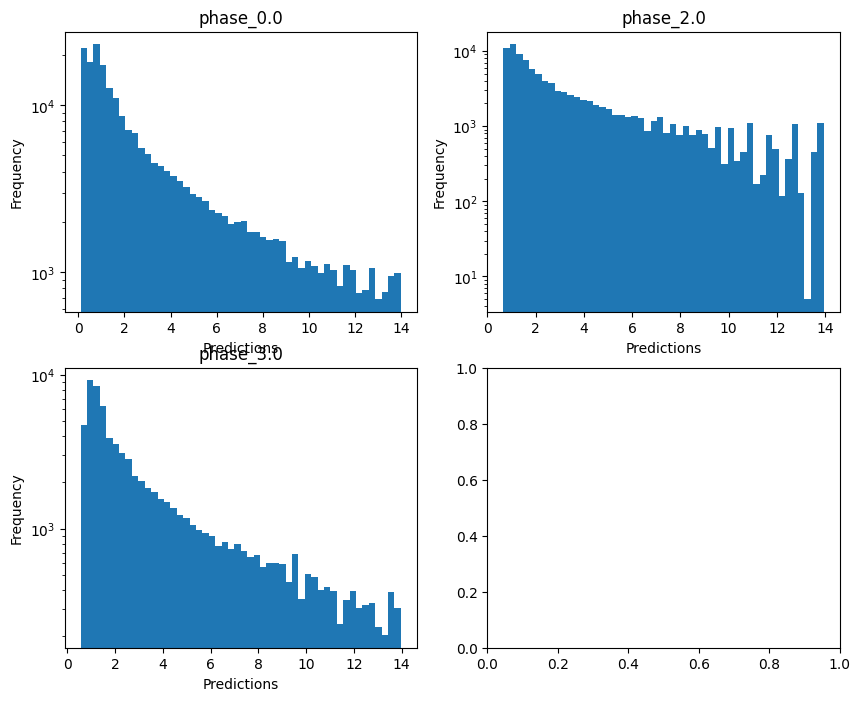

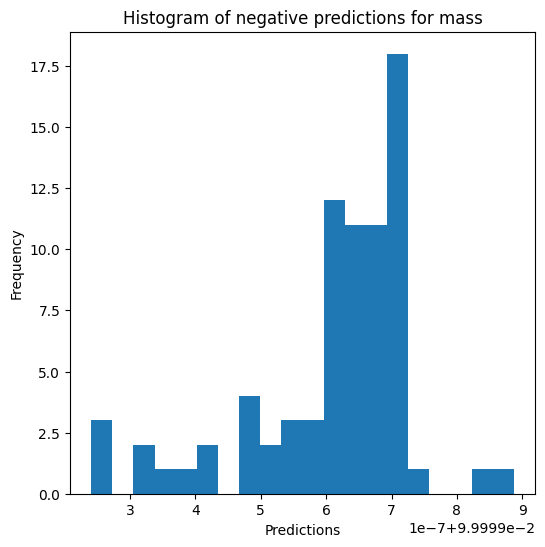


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999525480891372
  RMSE :  0.0029077918720357638
  MAE :  0.0016387588210390184
  MedAE :  0.0008957132687510416
  CORR :  0.999976298455771
  MAX_ER :  0.13380317213240334
  Percentiles : 
    75th percentile :  0.0019519156651162661
    90th percentile :  0.0038191393055900602
    95th percentile :  0.0056604590336003045
    99th percentile :  0.01148418502217701

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999217952761064
  RMSE :  0.004170378355688076
  MAE :  0.0028458463821408233
  MedAE :  0.0019097500035762383
  CORR :  0.9999619437448063
  MAX_ER :  0.05855108538544329
  Percentiles : 
    75th percentile :  0.0038167067958576467
    90th percentile :  0.006519490375168628
    95th percentile :  0.008632823528875889
    99th percentile :  0.014188254543058528

radius res

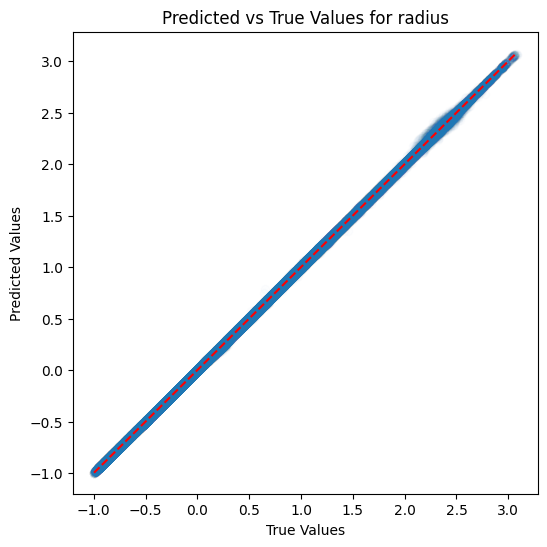

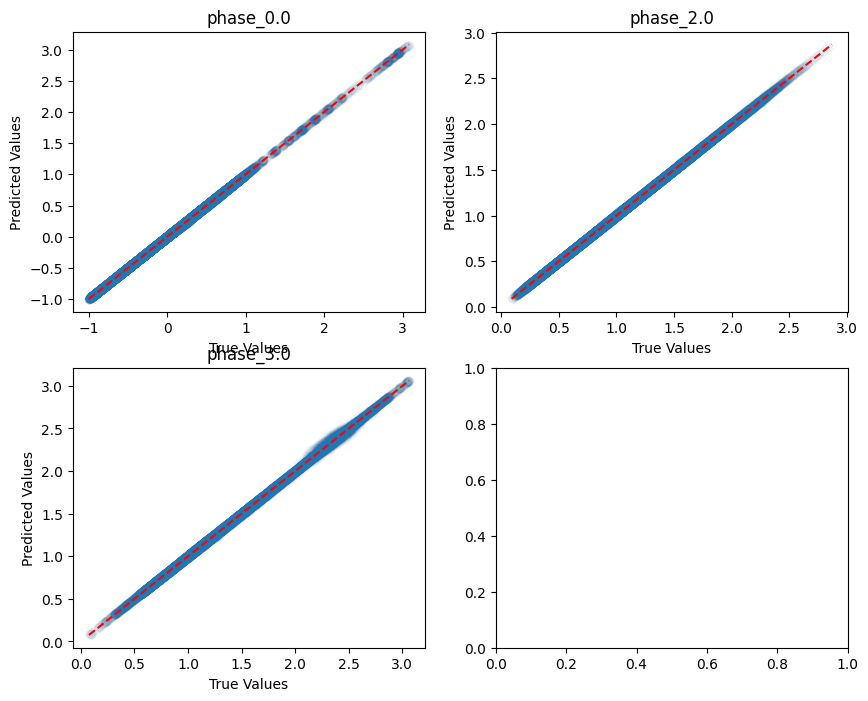

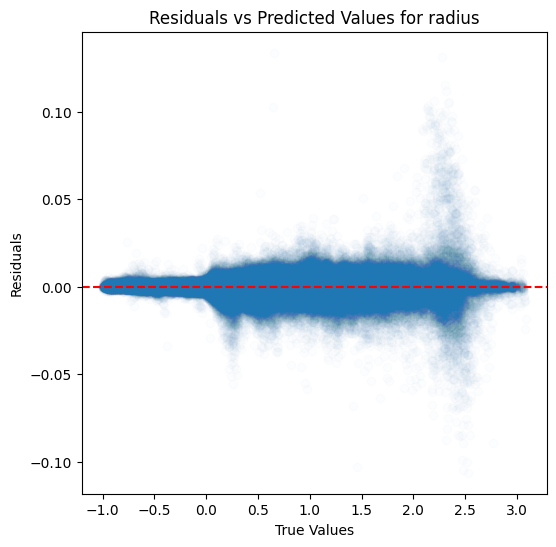

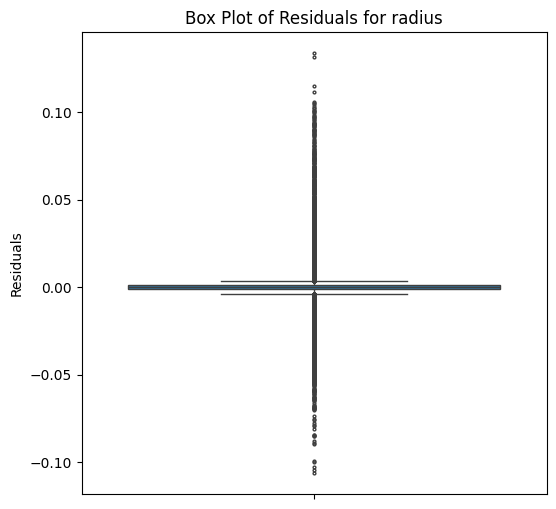

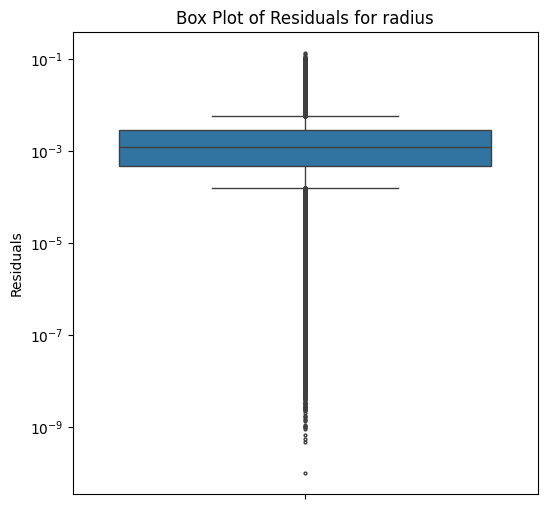

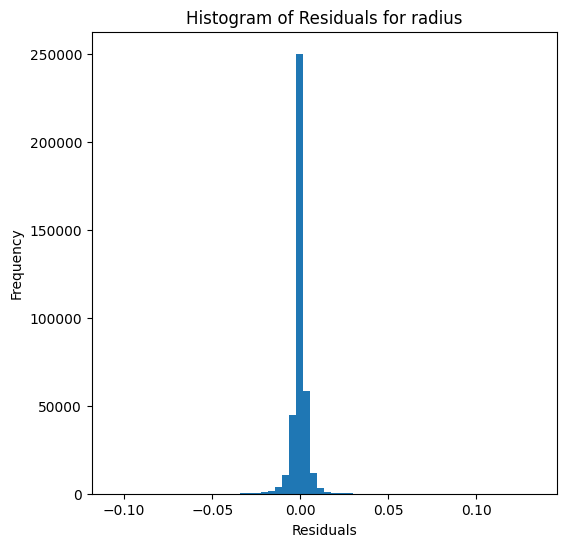

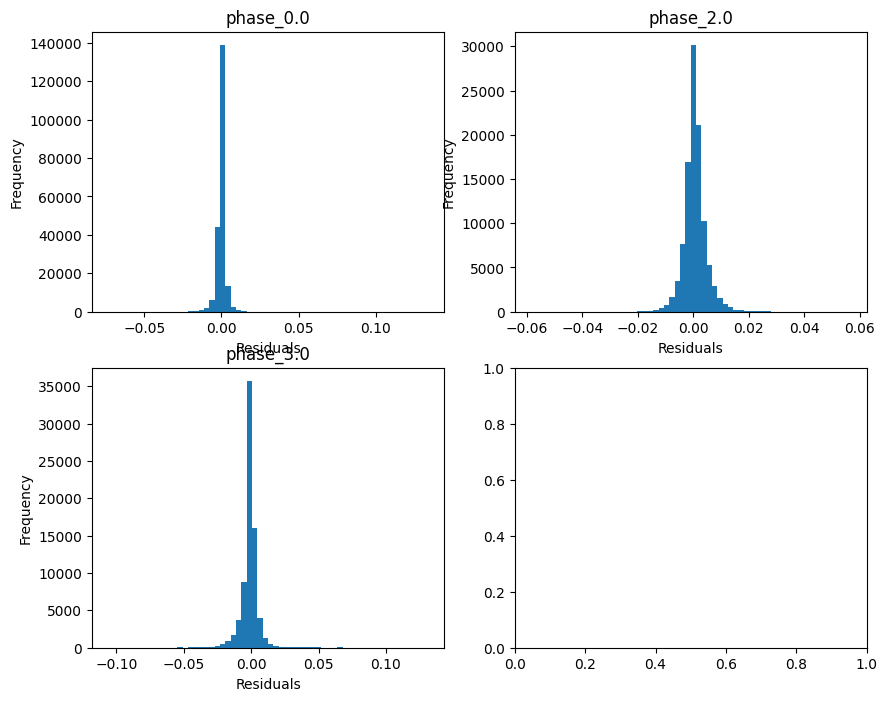

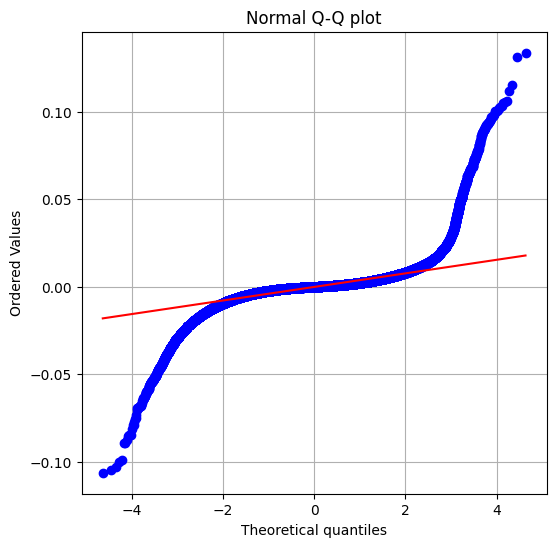

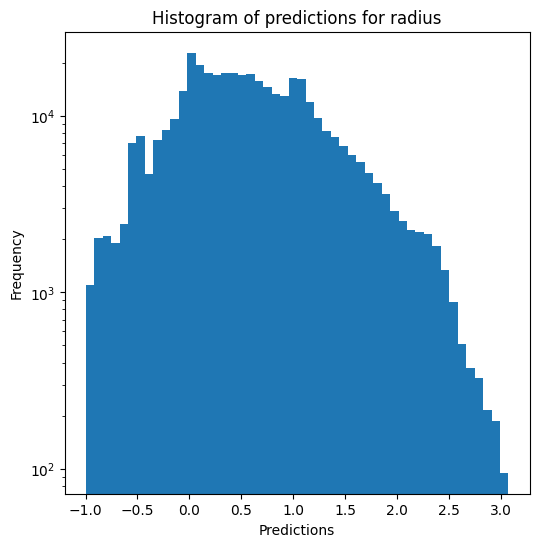

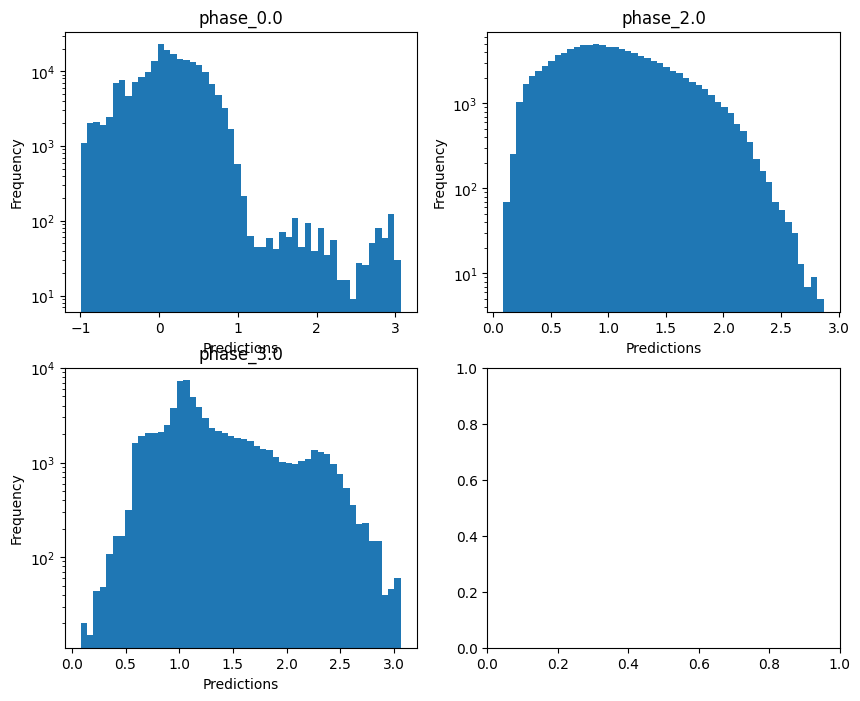

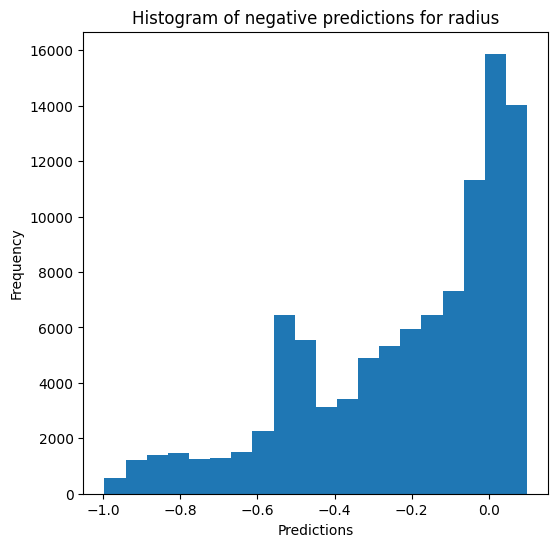

Saving predictions and results...


In [52]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [53]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.998785781846455
  RMSE :  0.11483543599111252
  MAE :  0.06418046611403287
  MedAE :  0.03173839806712553
  CORR :  0.999392746449869
  MAX_ER :  2.518846034395736
  Percentiles : 
    75th percentile :  0.07749676082187129
    90th percentile :  0.15716120439760603
    95th percentile :  0.23137056084869653
    99th percentile :  0.45445403636767423

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997564763853758
  RMSE :  0.052552116905014934
  MAE :  0.03587061906517909
  MedAE :  0.023327574922508032
  CORR :  0.9998842383868678
  MAX_ER :  0.695125616499638
  Percentiles : 
    75th percentile :  0.04860286818998394
    90th percentile :  0.0836847127972354
    95th percentile :  

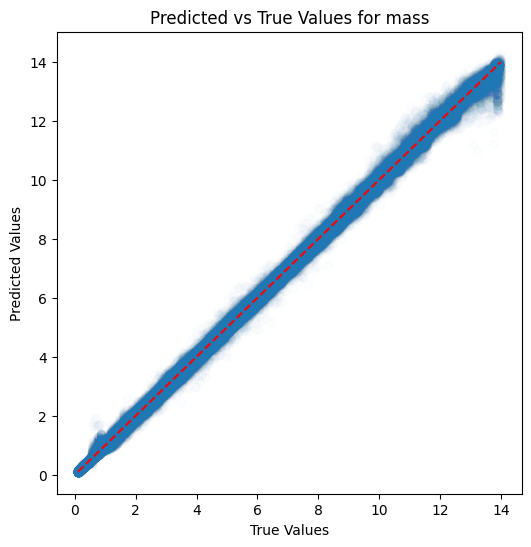

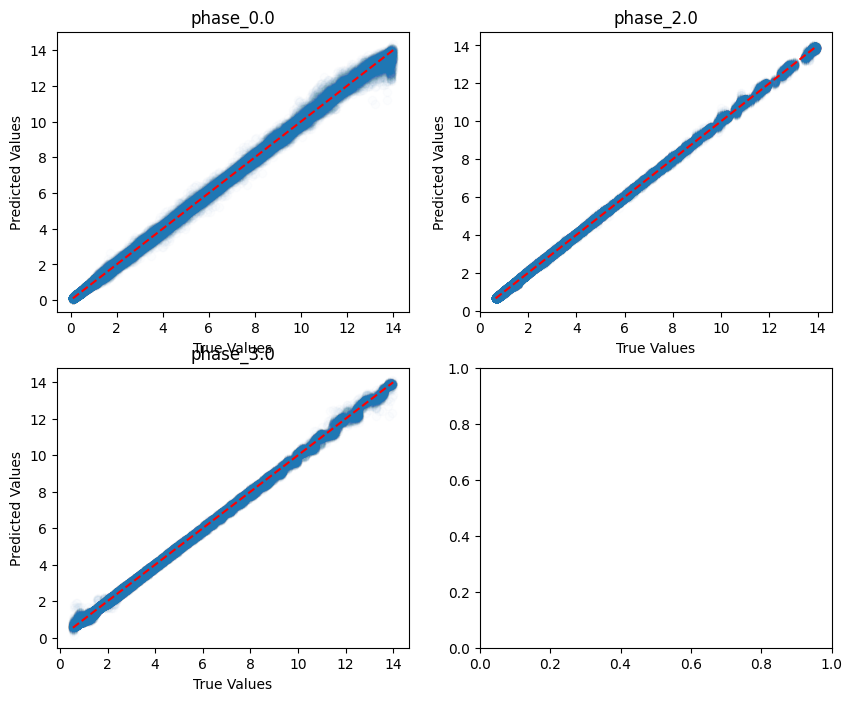

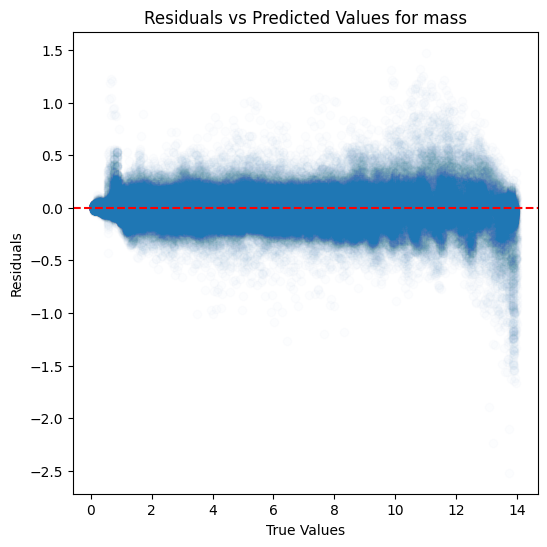

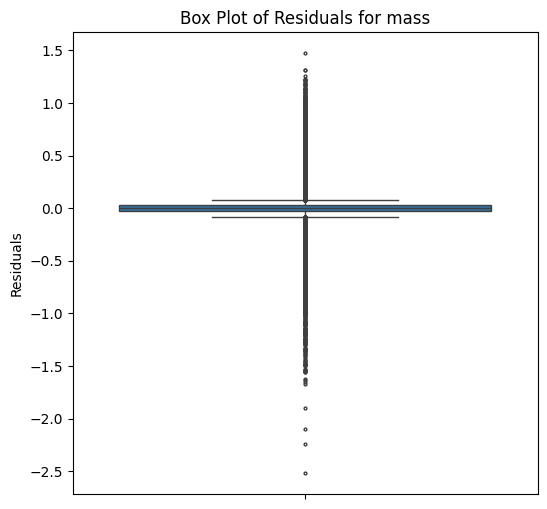

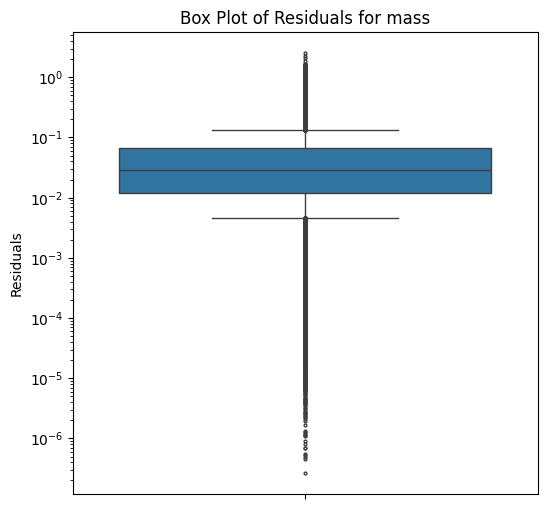

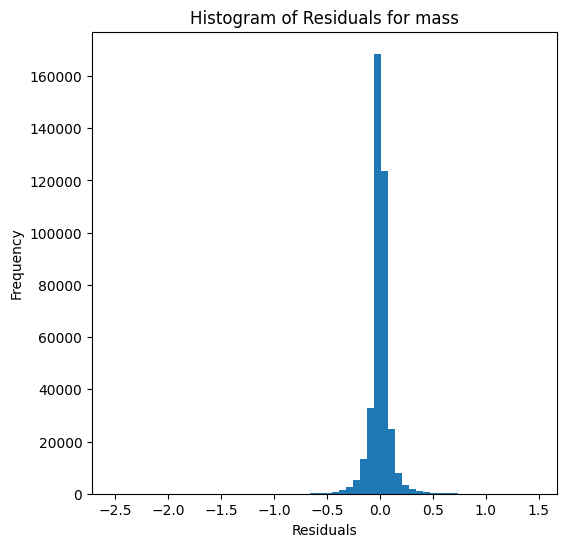

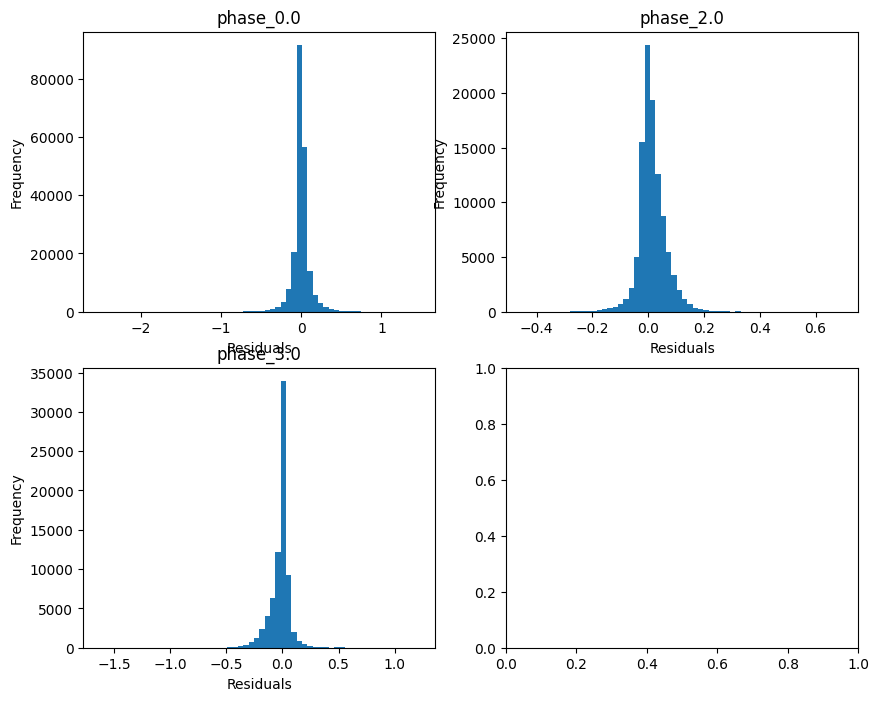

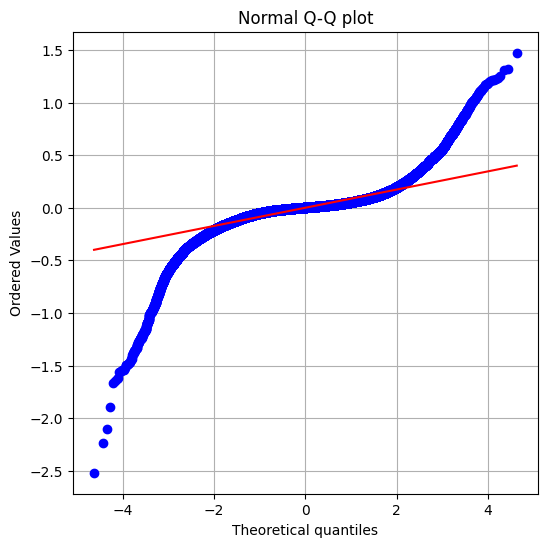

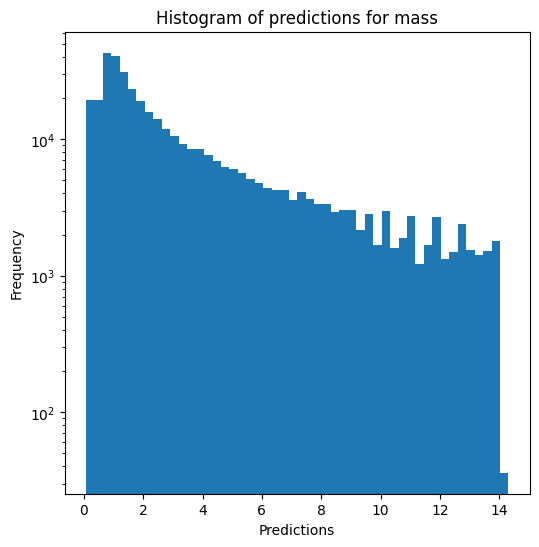

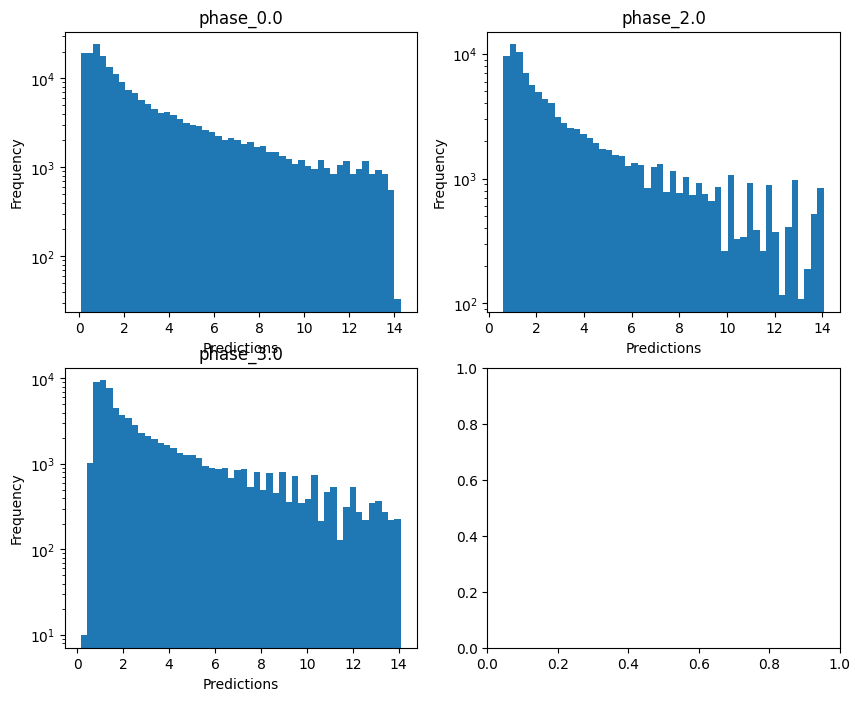

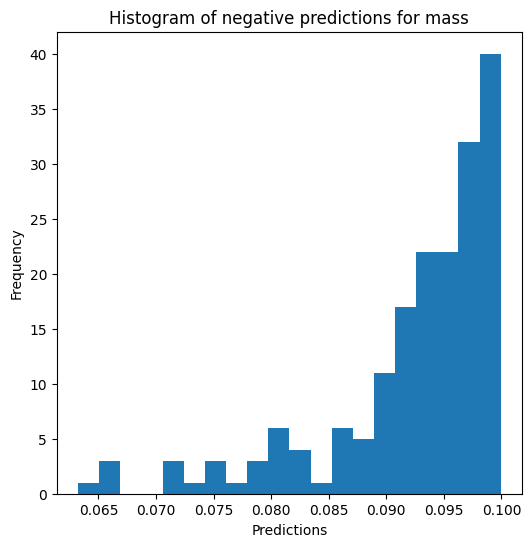


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9995097179849625
  RMSE :  0.009328053583799033
  MAE :  0.00709689775350331
  MedAE :  0.005565499816668484
  CORR :  0.9997548596414385
  MAX_ER :  0.05628001736506502
  Percentiles : 
    75th percentile :  0.009933163885666674
    90th percentile :  0.01523837821258106
    95th percentile :  0.019106216113498223
    99th percentile :  0.027292798687173984

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.999421070137597
  RMSE :  0.011235165764904768
  MAE :  0.008711115694325734
  MedAE :  0.0070367206923354075
  CORR :  0.9997107928501571
  MAX_ER :  0.07215287212604515
  Percentiles : 
    75th percentile :  0.012366954895188353
    90th percentile :  0.018365682097171265
    95th percentile :  0.02249069637616346
    99th percentile :  0.03138287877039677

radius results for th

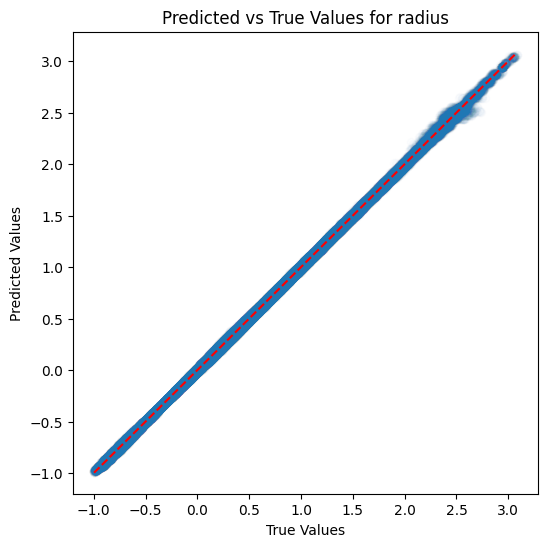

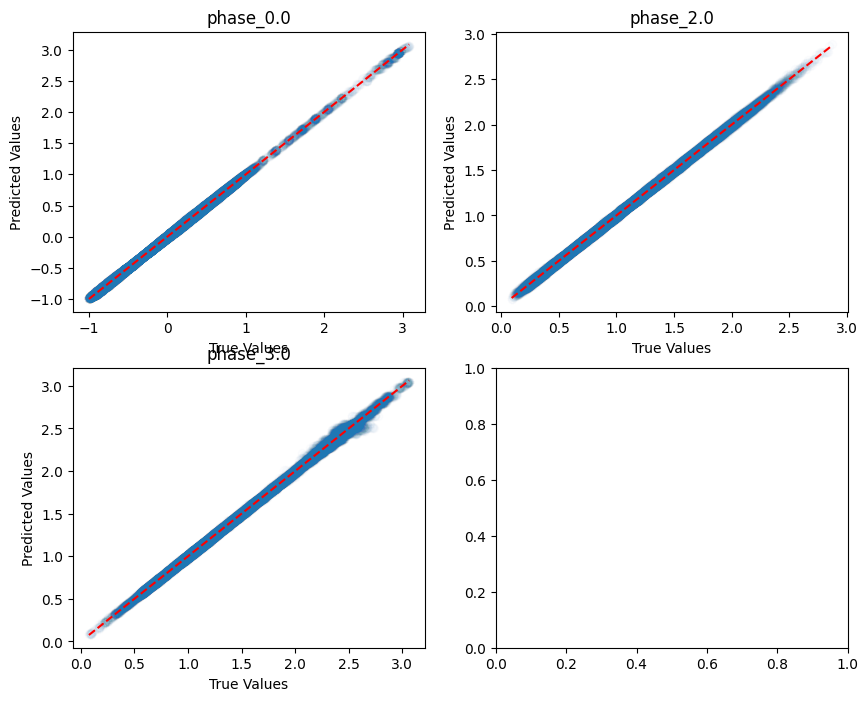

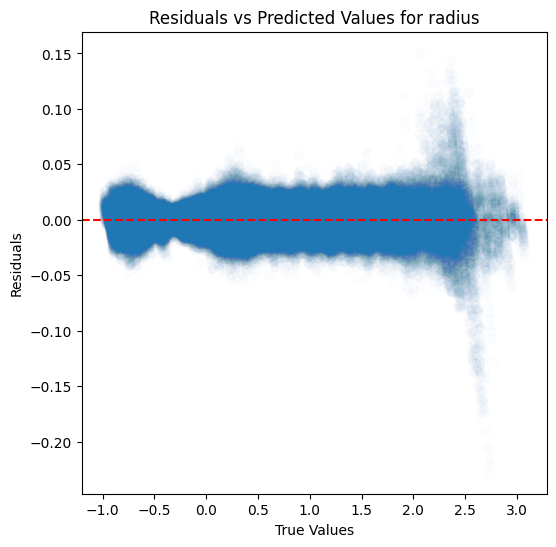

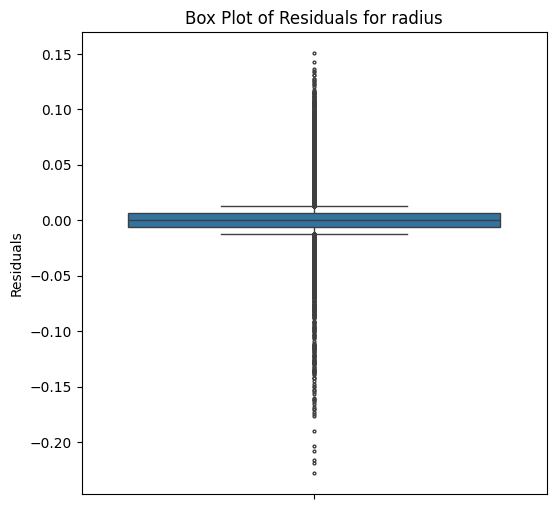

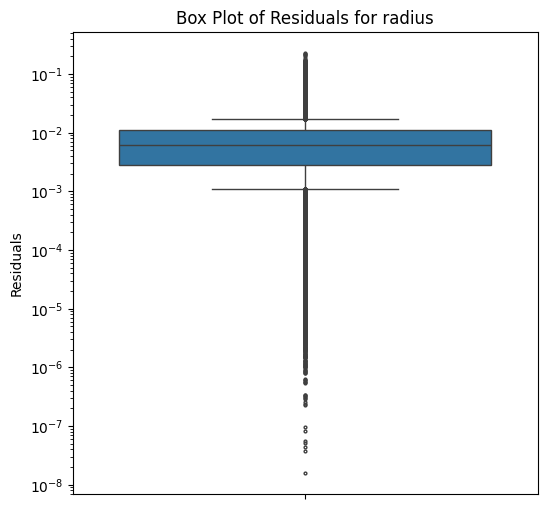

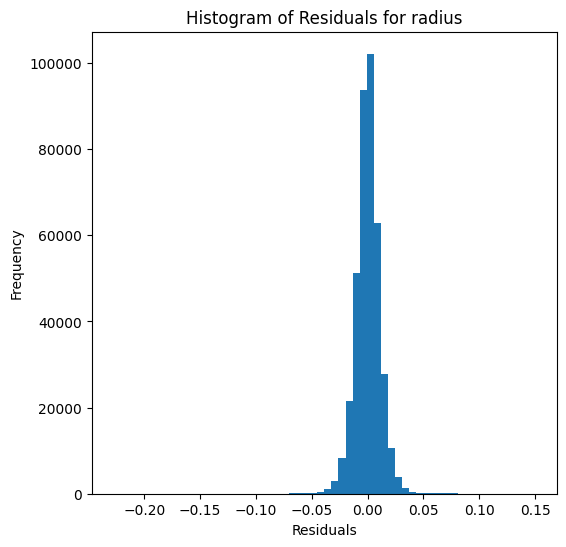

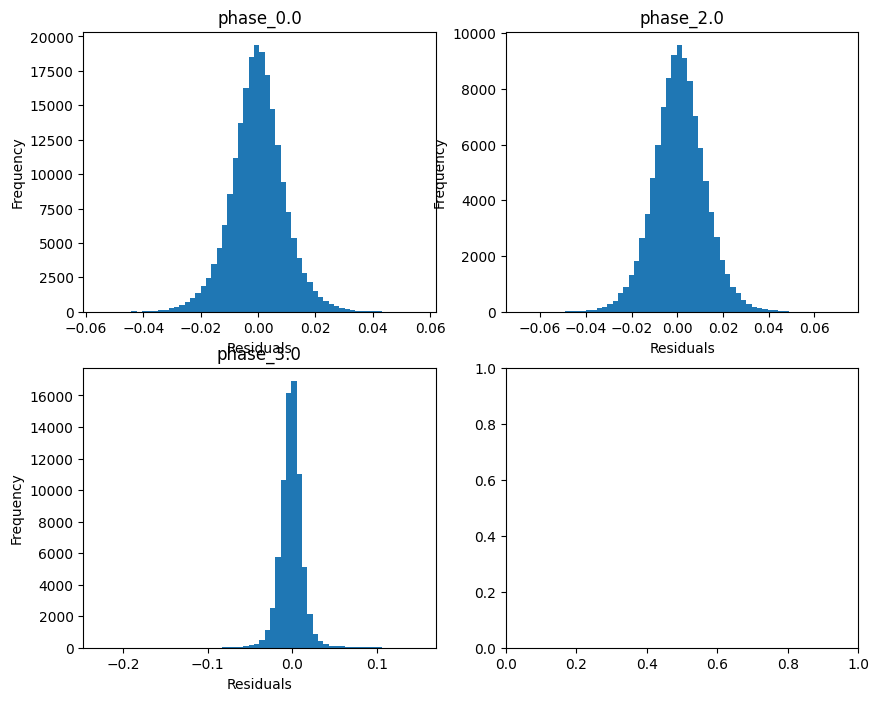

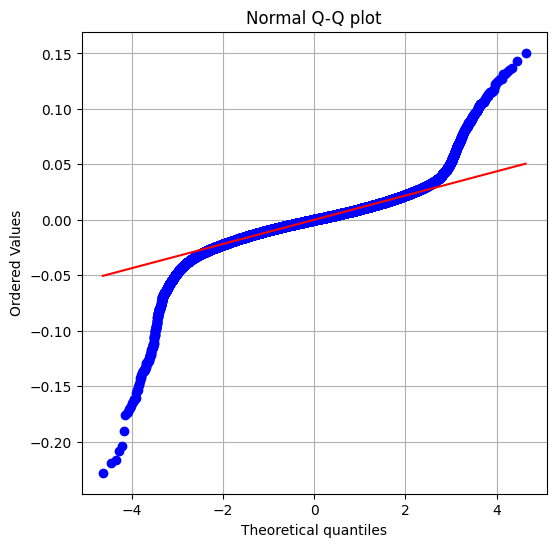

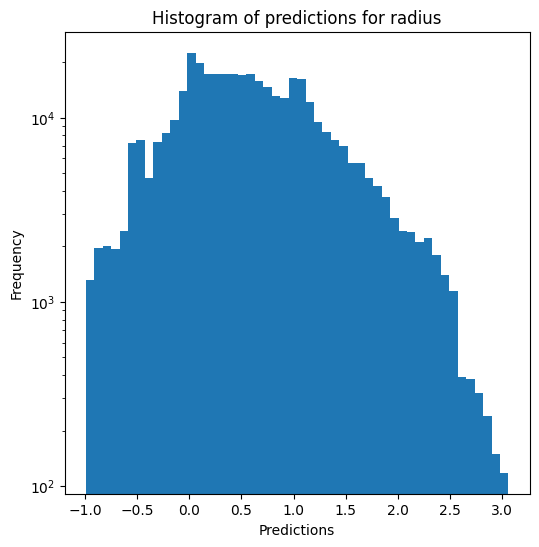

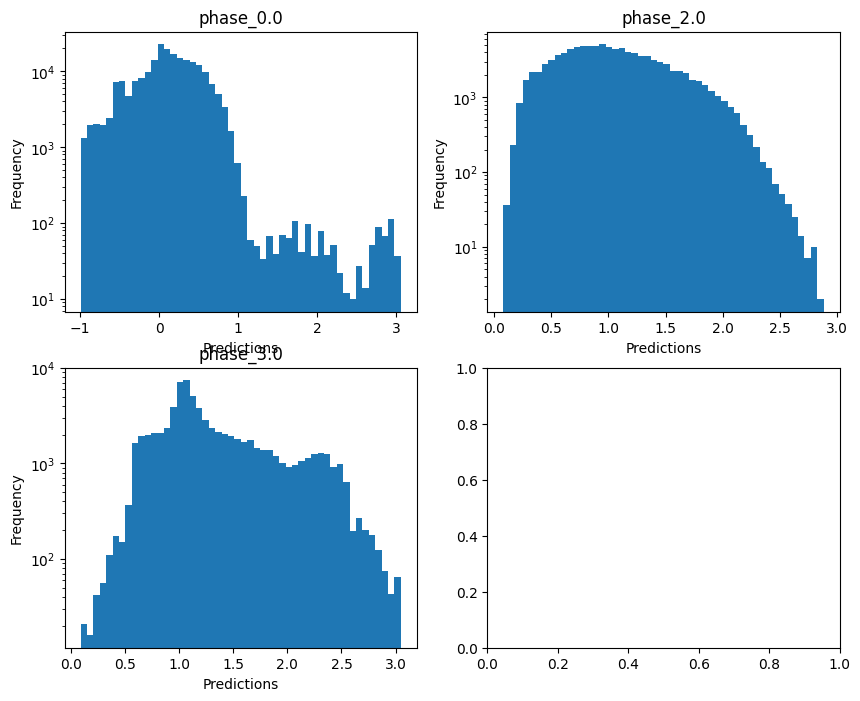

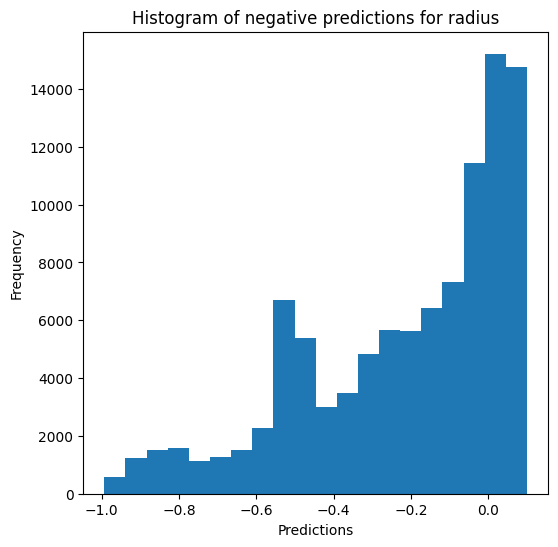

Saving predictions and results...


In [54]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [55]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power_14 train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0014599681330792933
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.001413582964710752
3 

...

0.0013583987739374094
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0014740145119389726
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0017263737007764375

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9996737228472234
  RMSE :  0.0596007867878333
  MAE :  0.029567348485475476
  MedAE :  0.015598228208128617
  CORR :  0.9998468207104646
  MAX_ER :  2.1241376528521485
  Percentiles : 
    75th percentile :  0.03147079177028633
    90th percentile :  0.06622789655921085
    95th percentile :  0.10315630580432396
    99th percentile :  0.22496524208825316

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997371178659273
  RMSE :  0.052667145595713456
  MAE :  0.030768916825074797
  MedAE :  0.01938820441389555
  CORR :  0.9998774088913329
  MAX_ER :  2.2547645588131573
  Percentiles : 
    75th percentile :  0.03854392774181481
    90th percentile :  0.06748094875137094
    95th percentile :  0.09316666115678145
    99th percentile :  0.1810

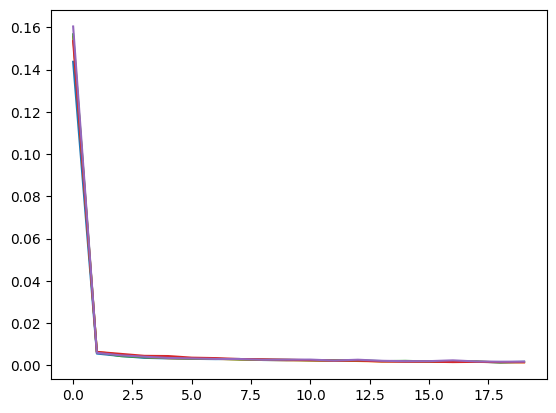

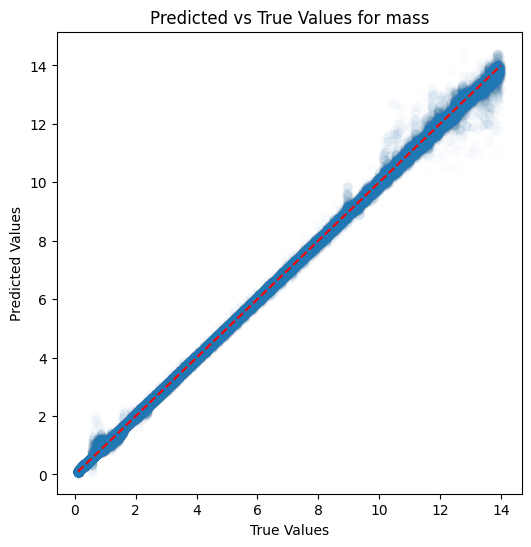

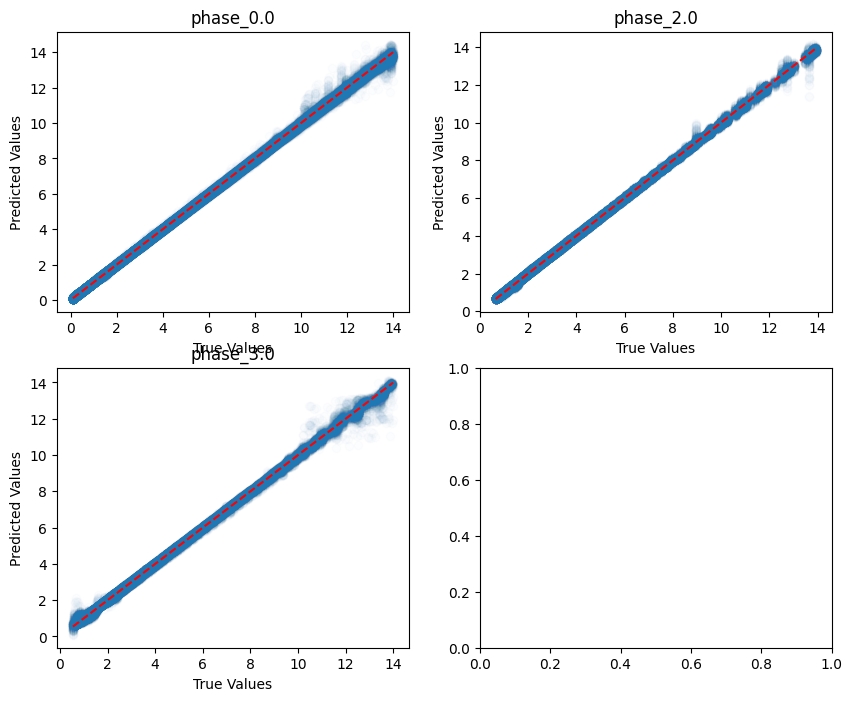

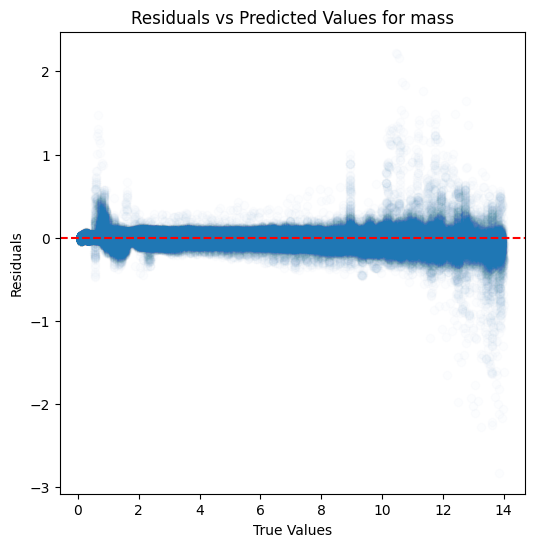

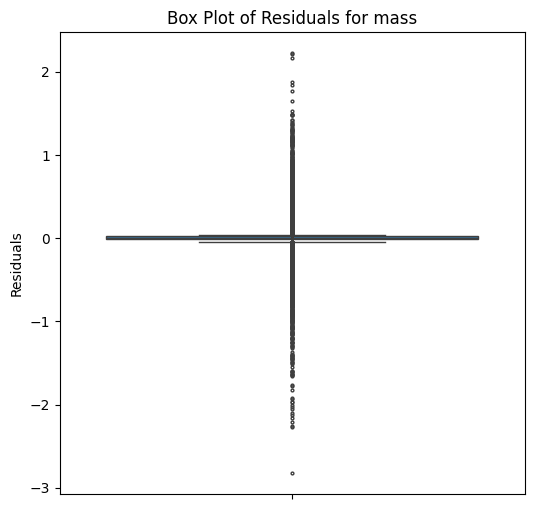

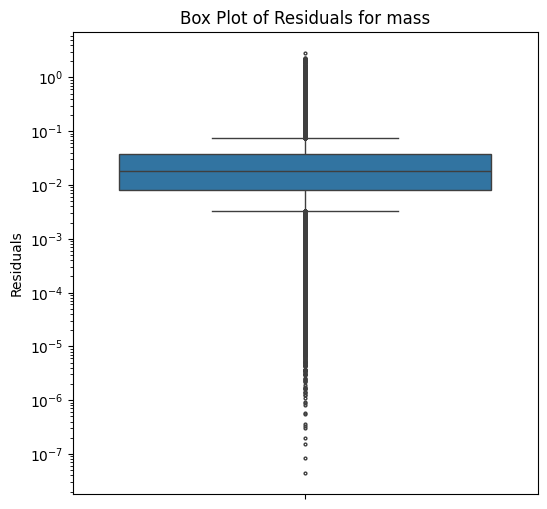

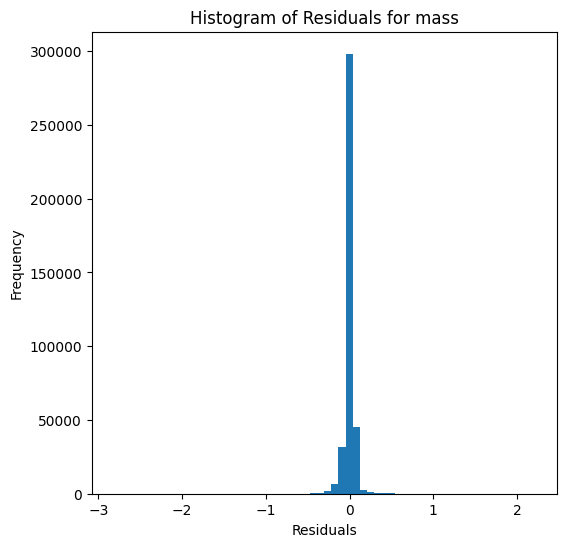

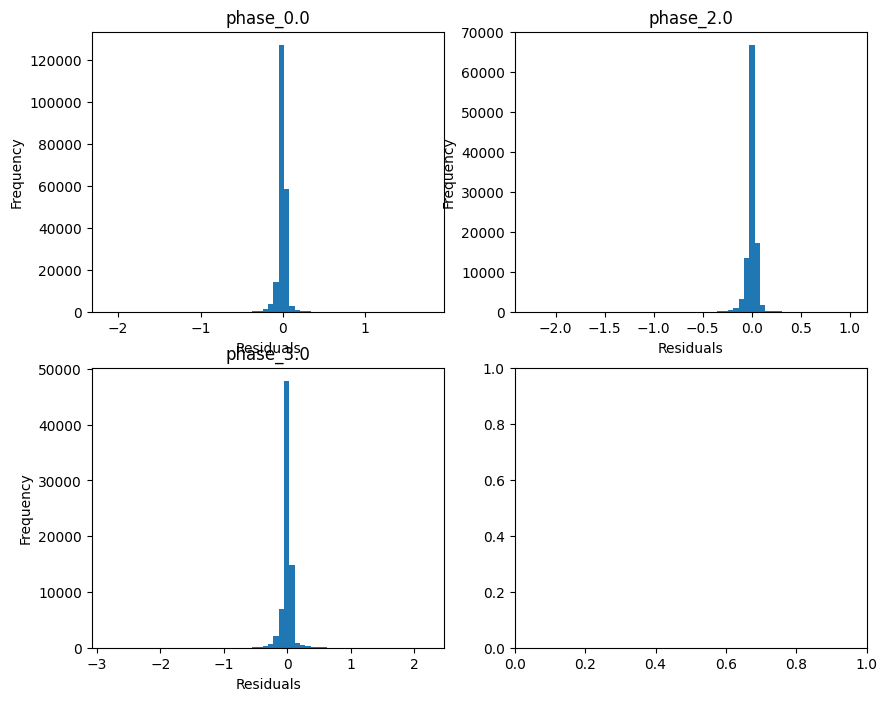

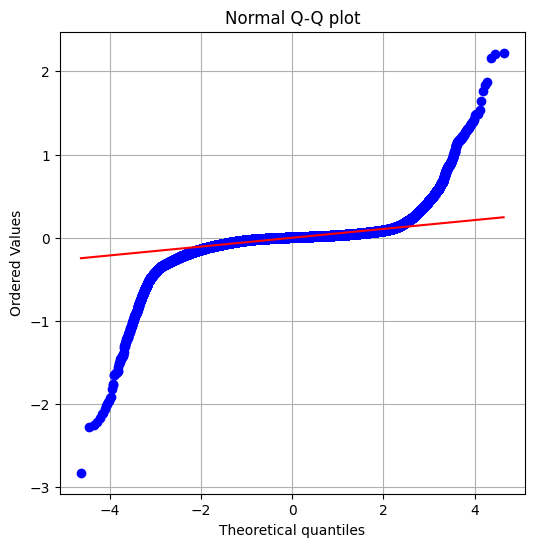

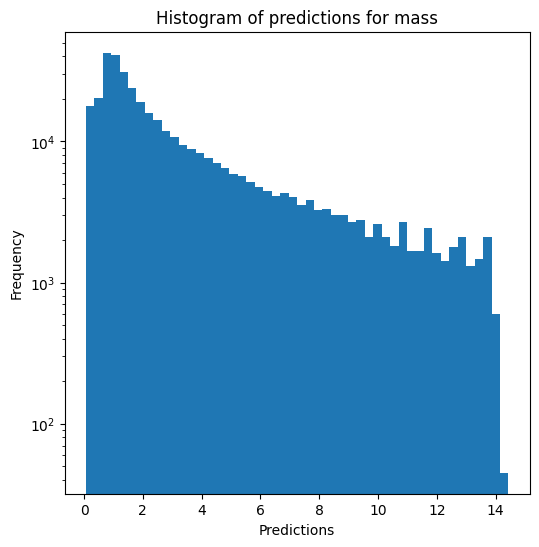

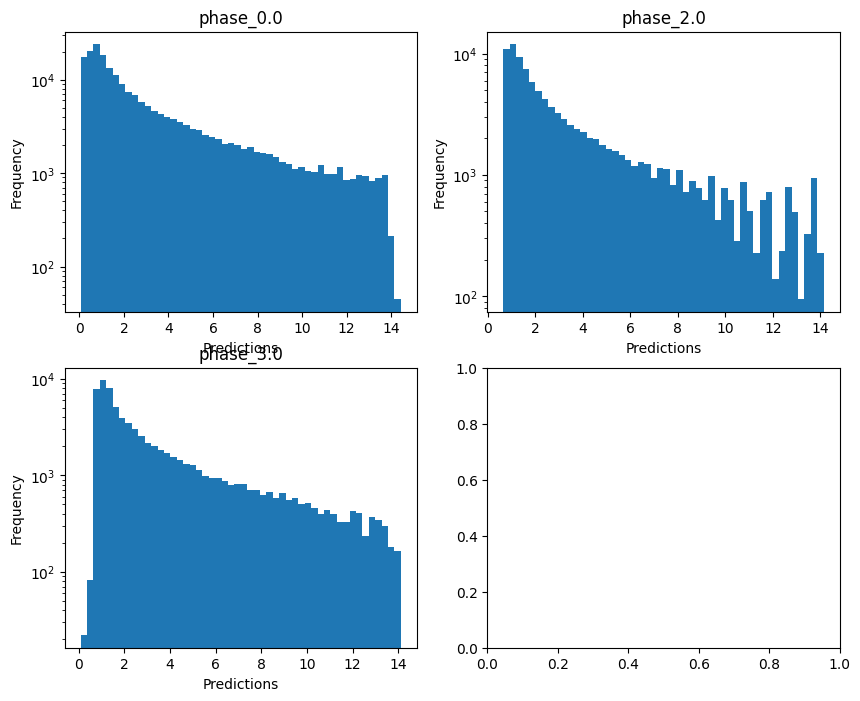

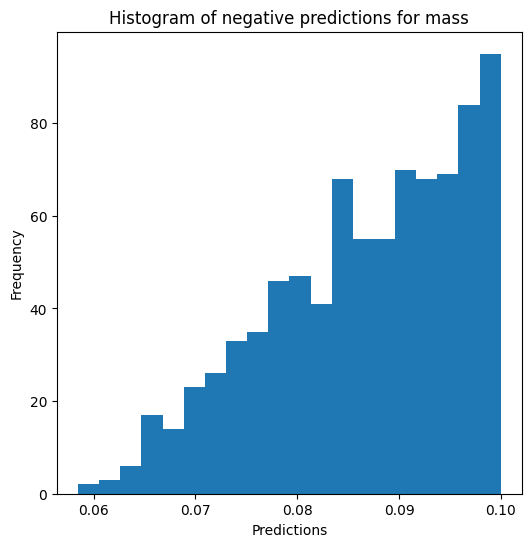


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9993175582265471
  RMSE :  0.0111919313364176
  MAE :  0.008627245065051263
  MedAE :  0.0070794979481222375
  CORR :  0.999678373809654
  MAX_ER :  0.15401394274079827
  Percentiles : 
    75th percentile :  0.012168867417285512
    90th percentile :  0.017842238757164532
    95th percentile :  0.021717230116770733
    99th percentile :  0.030573357633331376

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9990454026224644
  RMSE :  0.014402784813045516
  MAE :  0.0111132372587262
  MedAE :  0.008832964500682161
  CORR :  0.9995262402426002
  MAX_ER :  0.0909411537852769
  Percentiles : 
    75th percentile :  0.015820330096129792
    90th percentile :  0.023996909247009916
    95th percentile :  0.029328607079430045
    99th percentile :  0.03938232488079763

radius results for the 

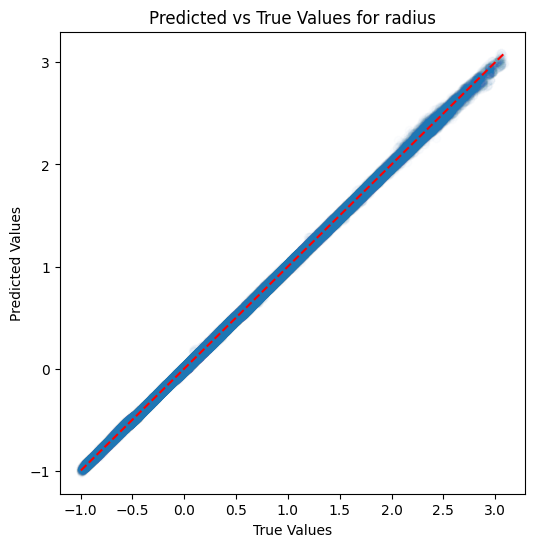

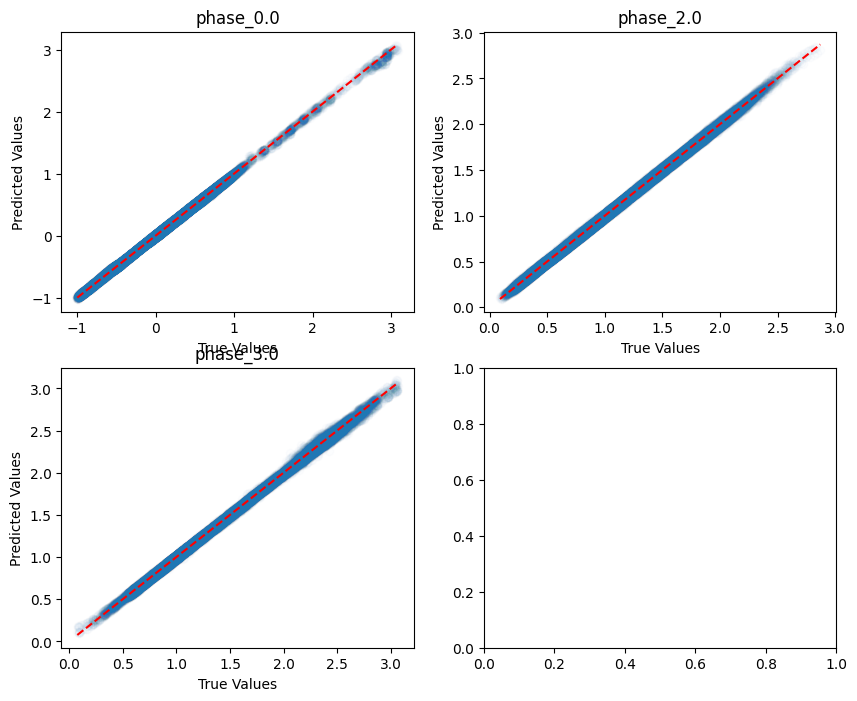

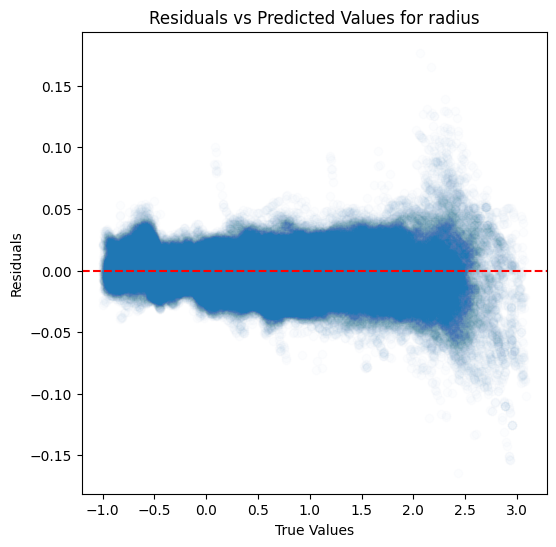

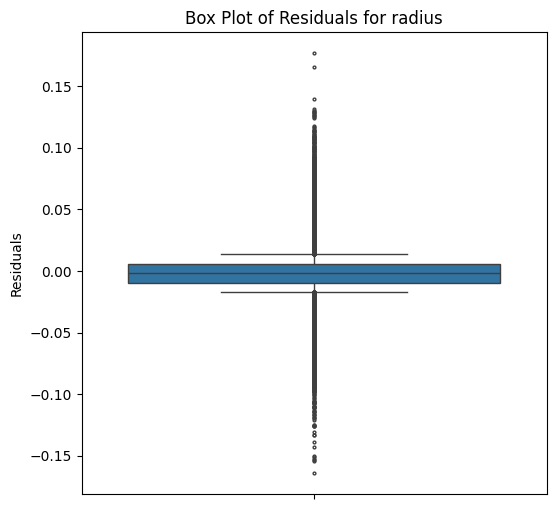

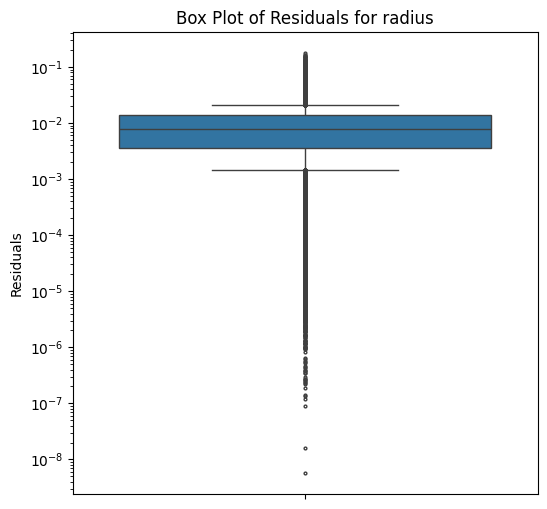

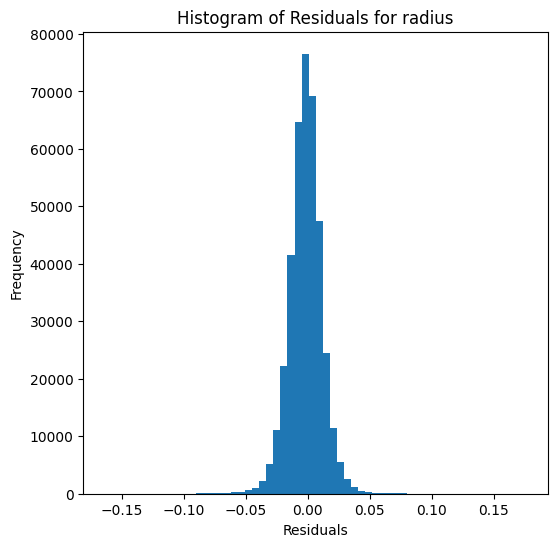

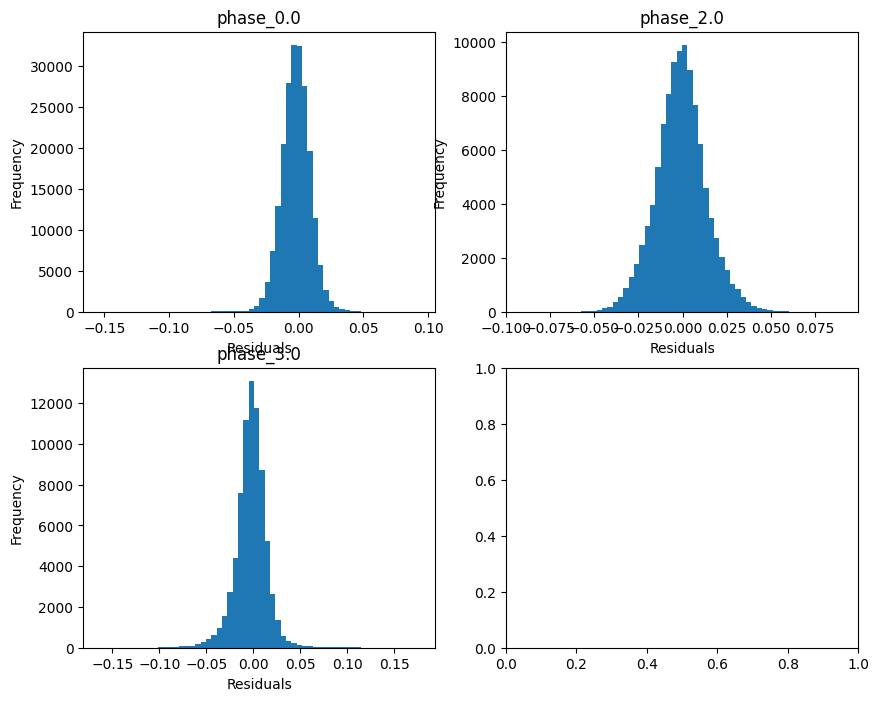

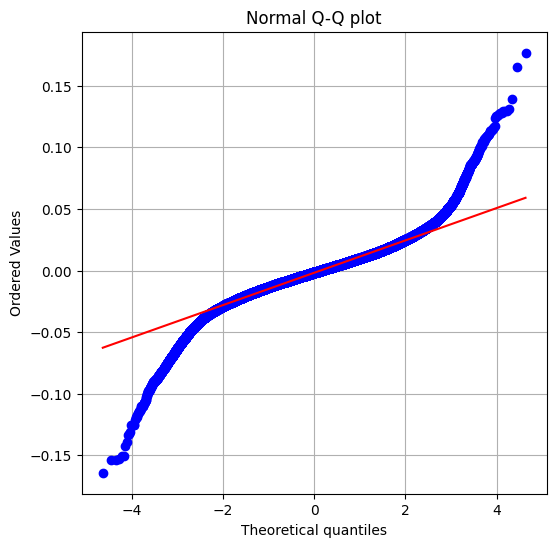

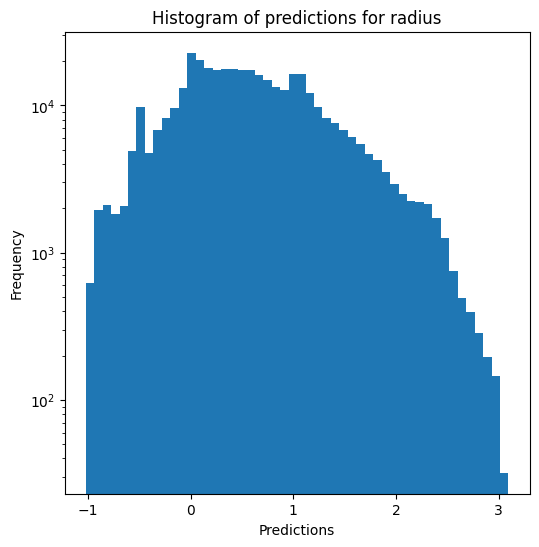

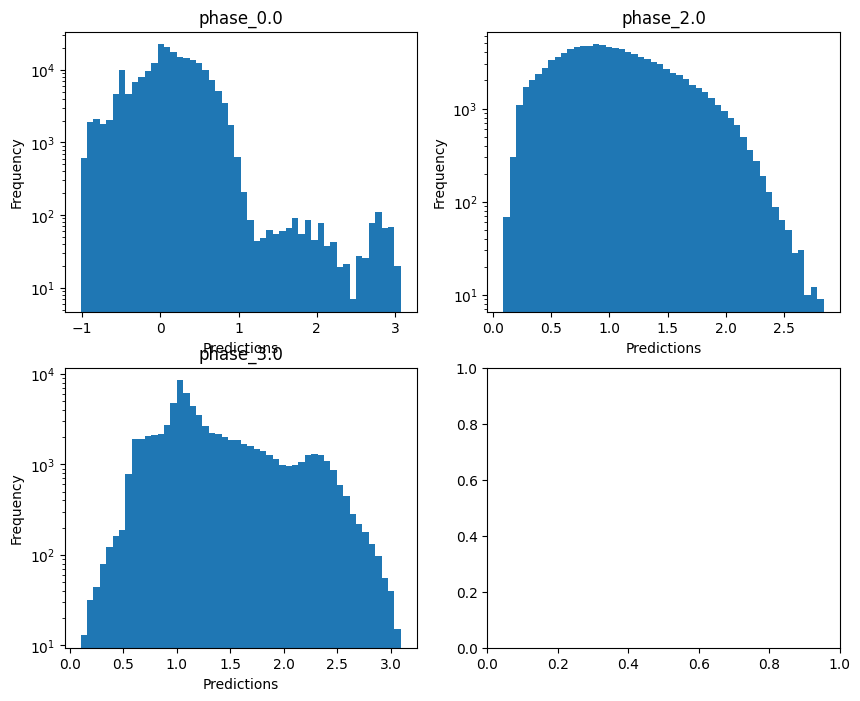

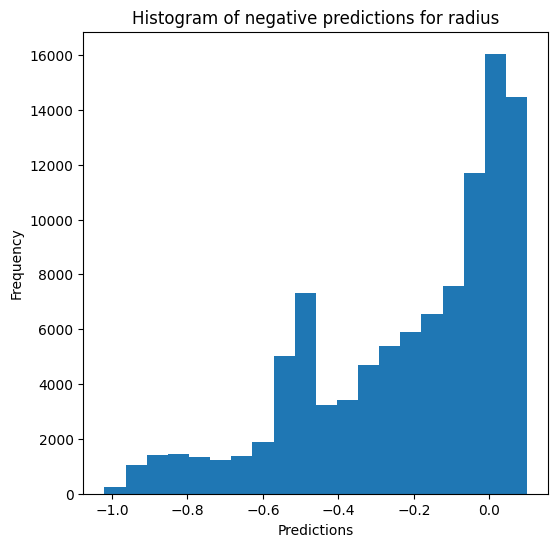

Saving predictions and results...


In [56]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon